In [1]:
import numpy as np
from starred.utils.generic_utils import make_grid, gaussian_function, fwhm2sigma, Downsample
import matplotlib.pyplot as plt 
from starred.procedures.psf_routines import narrow_psf_from_model
from starred.psf.psf import PSF
from starred.plots.plot_function import single_PSF_plot
import skimage

# Obtaining `s`, the narrow PSF, at the same resolution than the input PSF model: 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
#############################################
Subsampling in: 1
Original PSF size: 64
0.99999976 0.9999998


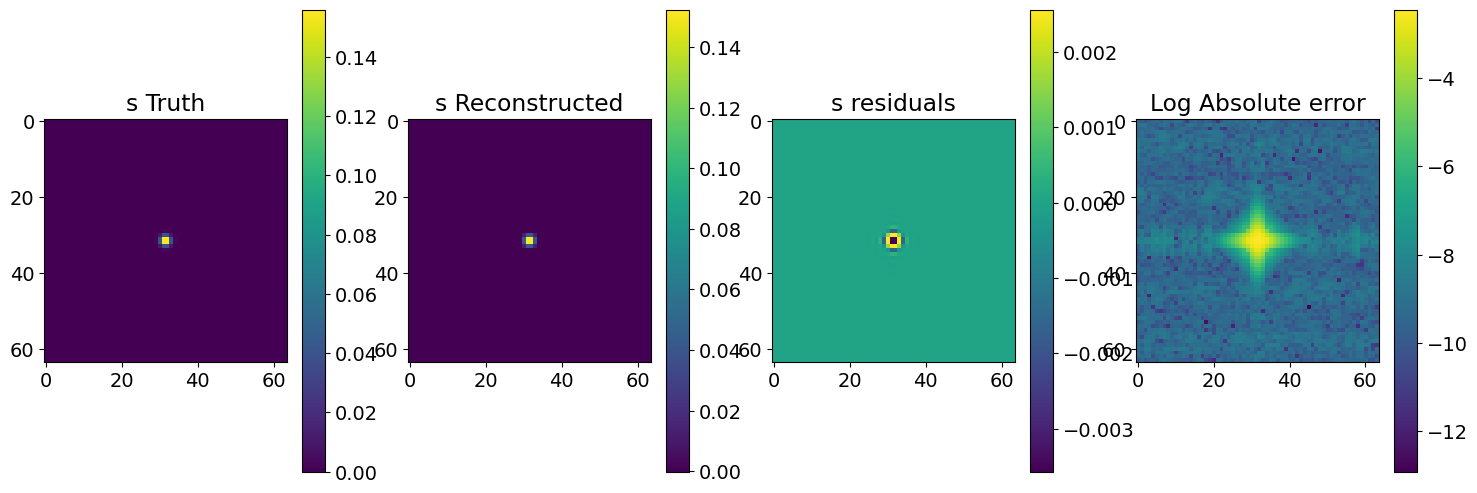

Max error / max PSF, narrow PSF: 0.022843631
MAE : 1.5171734e-05


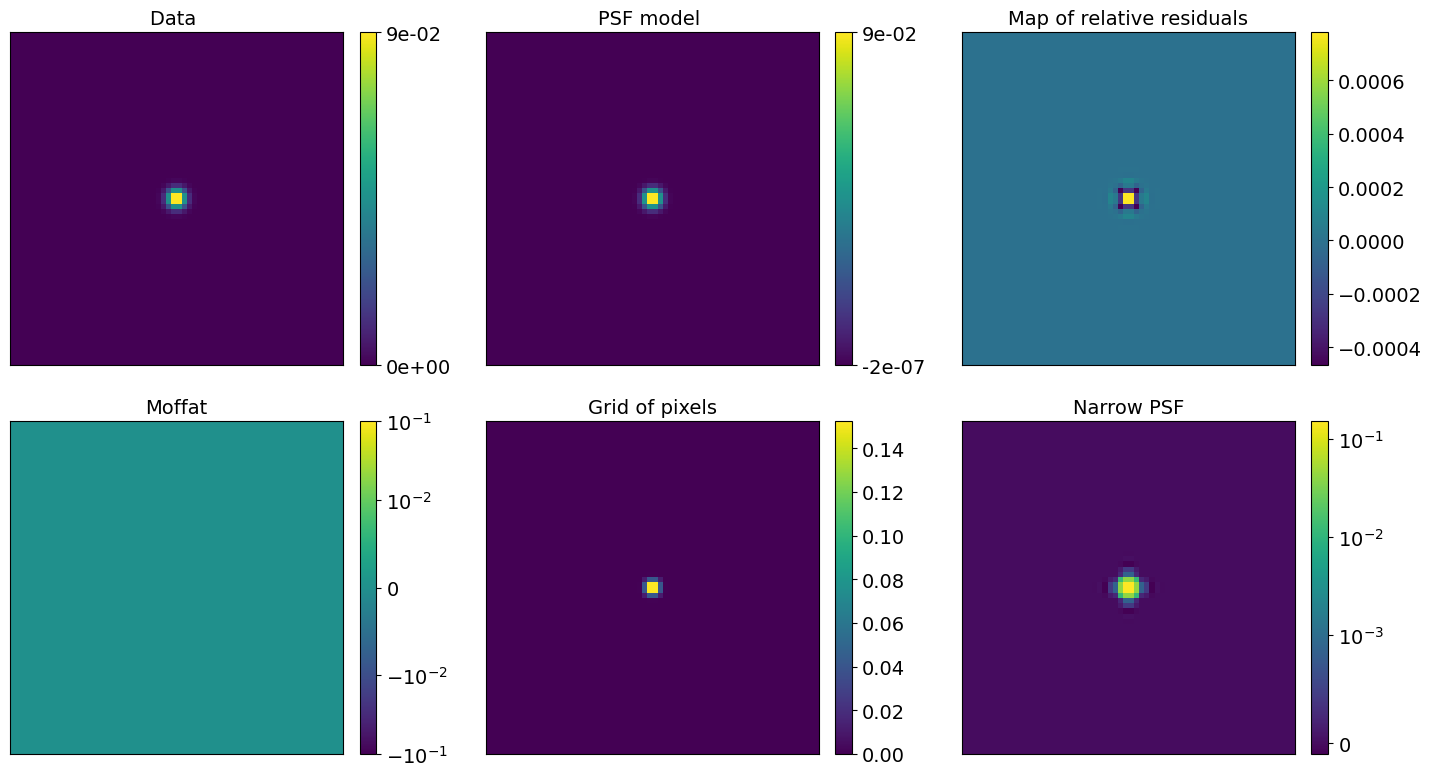

Max error / max PSF, full PSF: 0.0007787645
MAE : 2.2558065e-06
#############################################
Subsampling in: 1
Original PSF size: 65
1.0 1.0


/var/folders/k5/9nxb2fnj4zsbb1nrtpvbf8000000gn/T/ipykernel_82932/135793330.py:53: RuntimeWarning: divide by zero encountered in log10
  fig.colorbar(axes[3].imshow(np.log10(np.abs(narrow_psf_reconstructed - narrow_psf_truth))))


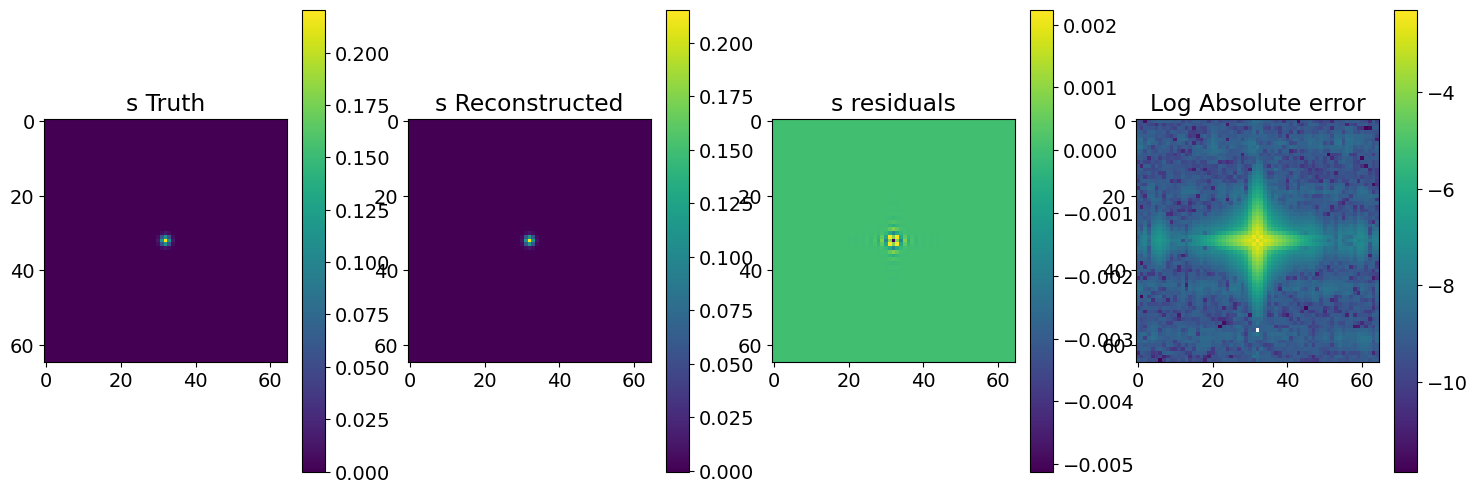

Max error / max PSF, narrow PSF: 0.02319714
MAE : 1.0481604e-05


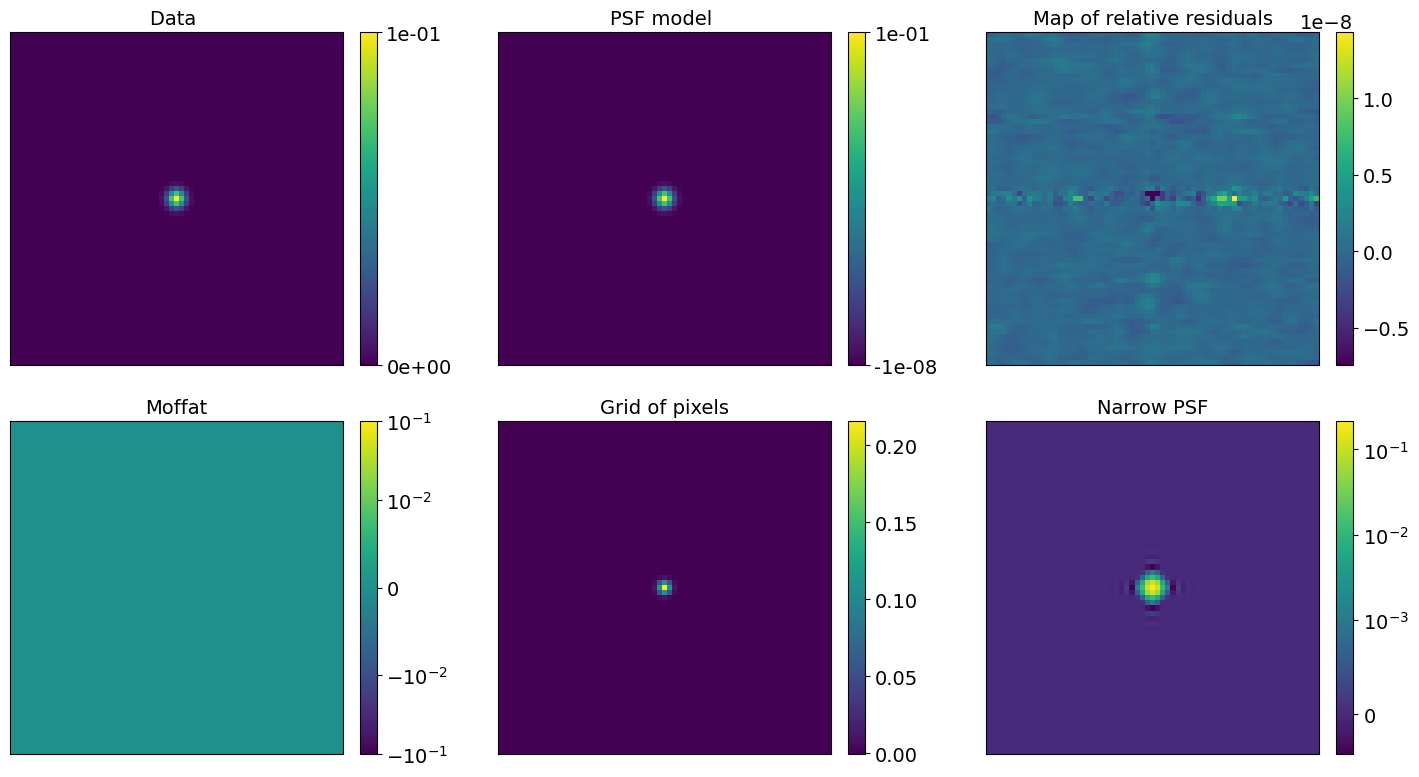

Max error / max PSF, full PSF: 3.7252903e-08
MAE : 4.8884763e-10
#############################################
Subsampling in: 2
Original PSF size: 64
1.0 0.9999999


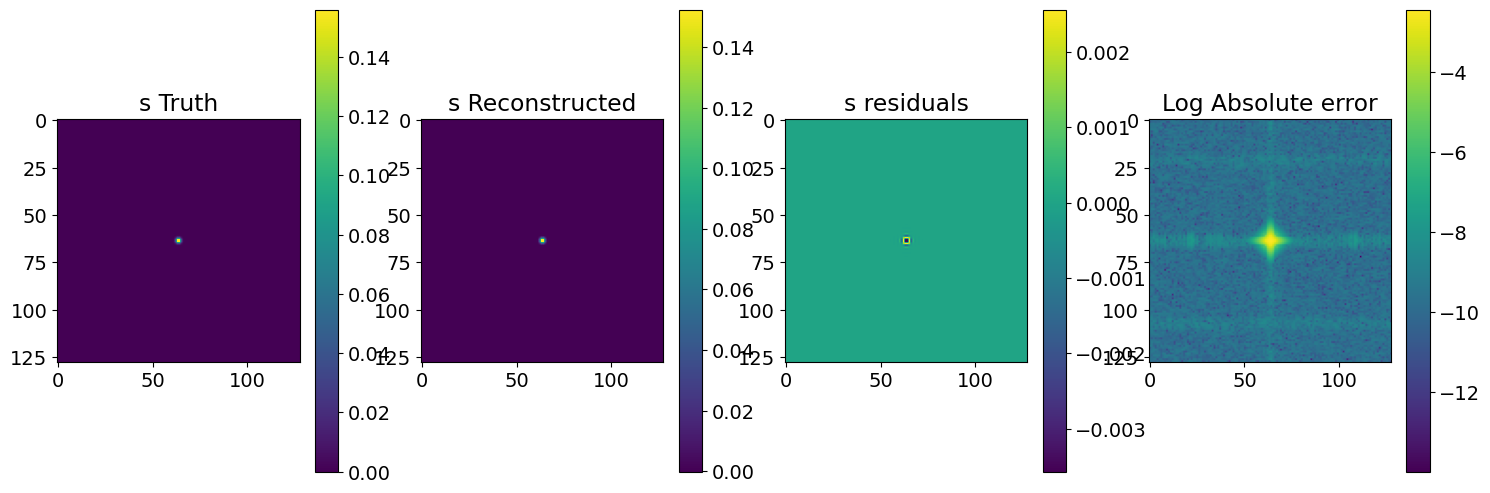

Max error / max PSF, narrow PSF: 0.022843726
MAE : 3.793093e-06


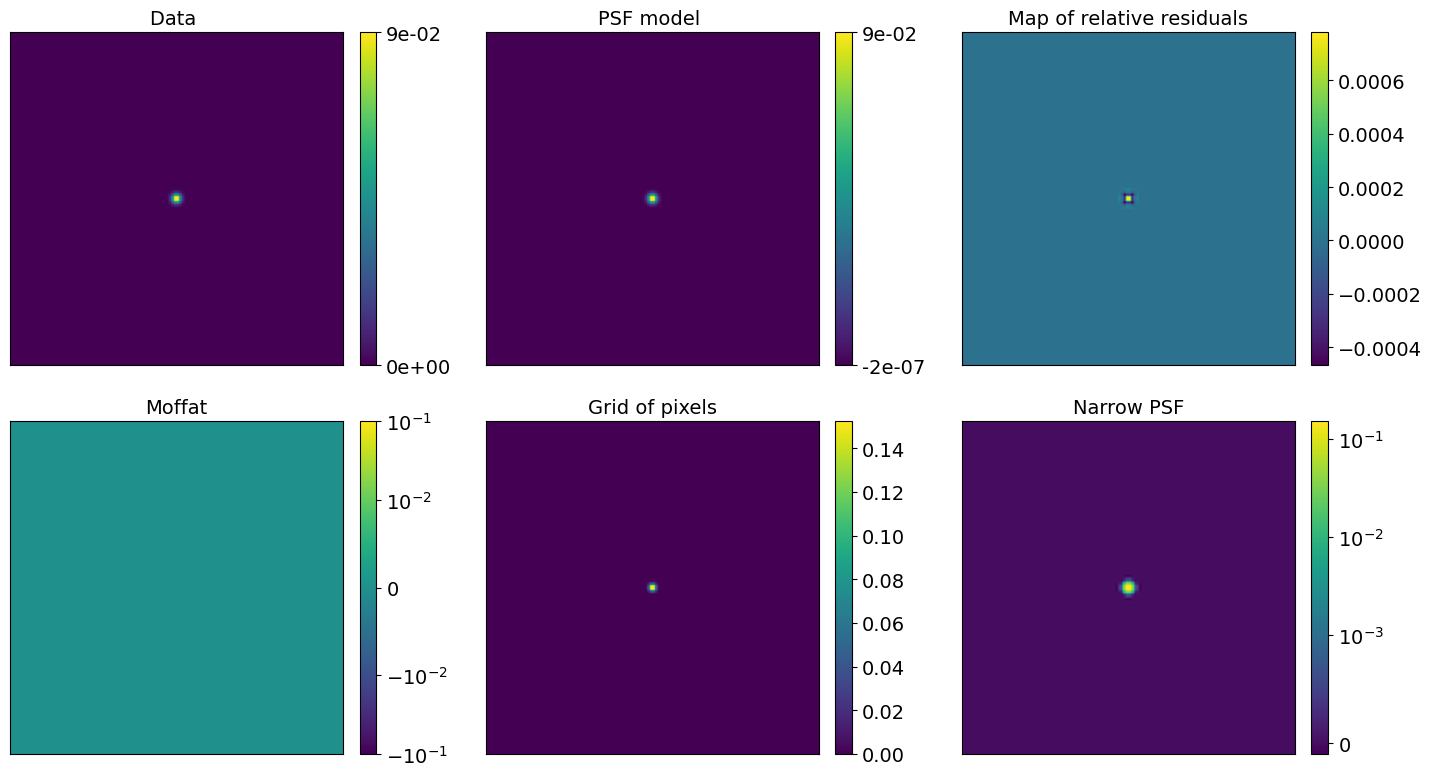

Max error / max PSF, full PSF: 0.00077880174
MAE : 5.640861e-07
#############################################
Subsampling in: 2
Original PSF size: 65
1.0 0.9999998


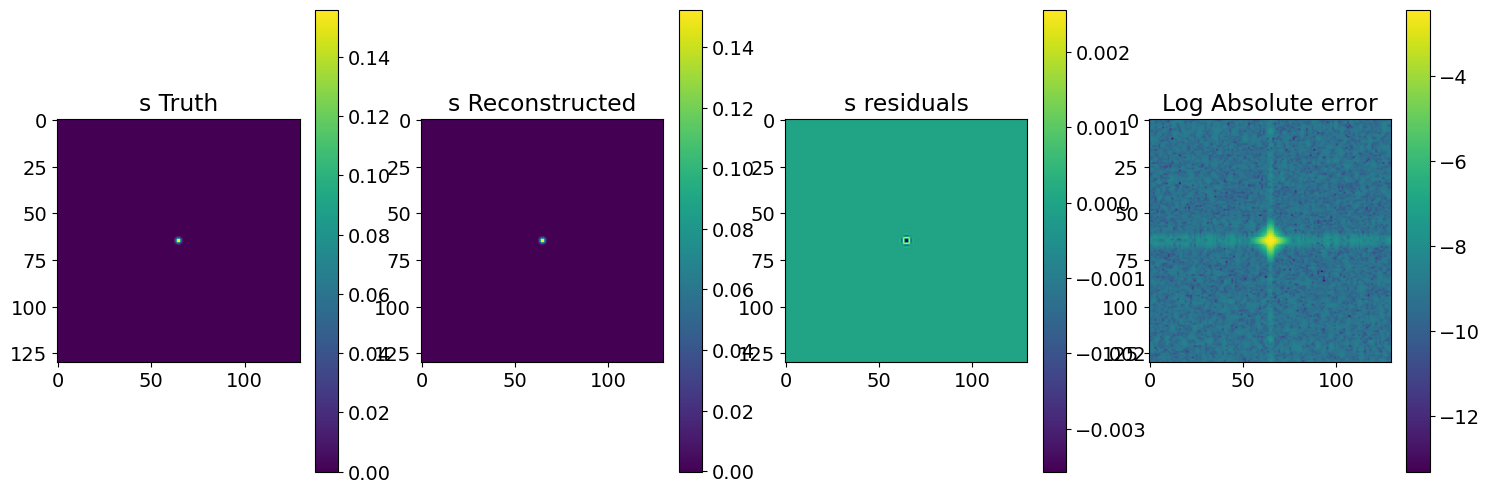

Max error / max PSF, narrow PSF: 0.022843726
MAE : 3.67796e-06


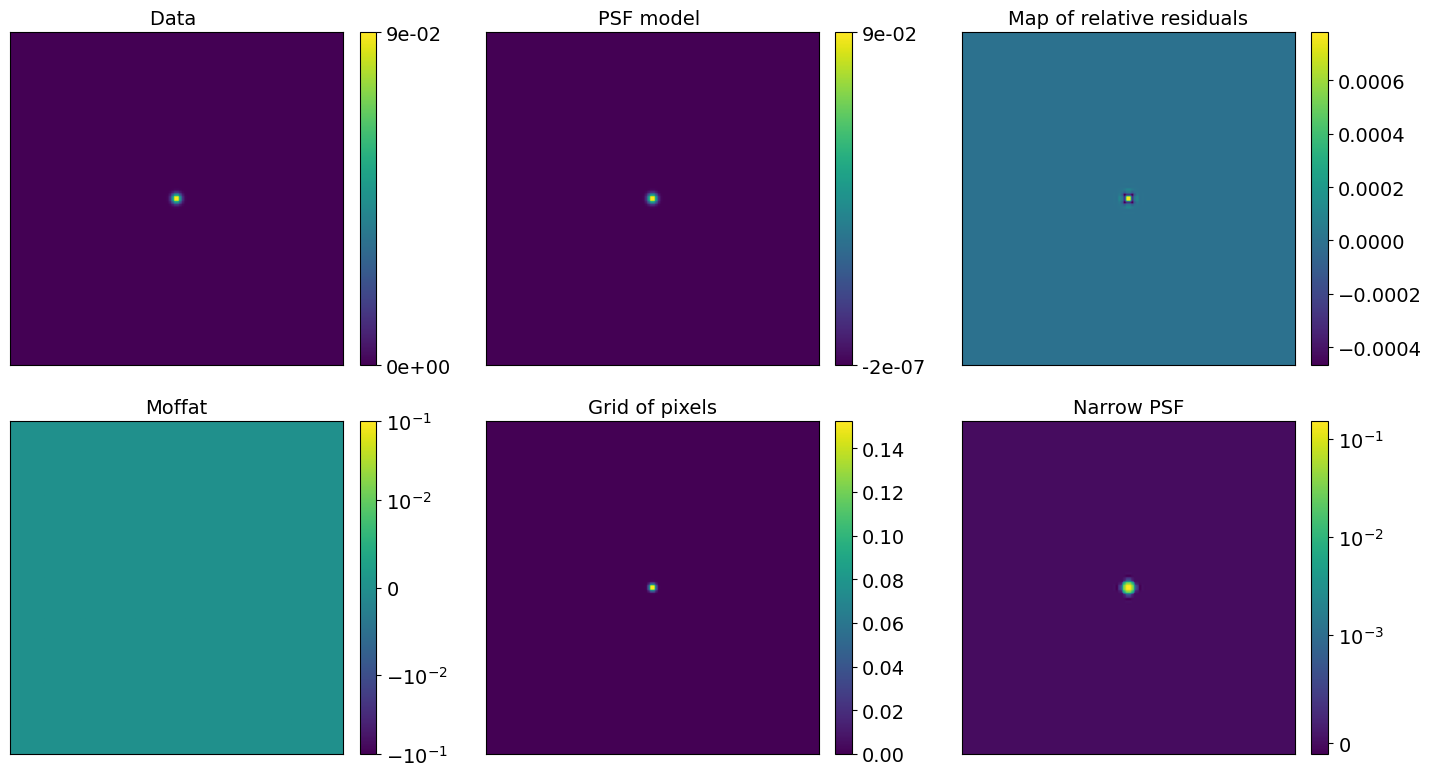

Max error / max PSF, full PSF: 0.0007787943
MAE : 5.469428e-07
#############################################
Subsampling in: 3
Original PSF size: 64
1.0000001 0.9999998


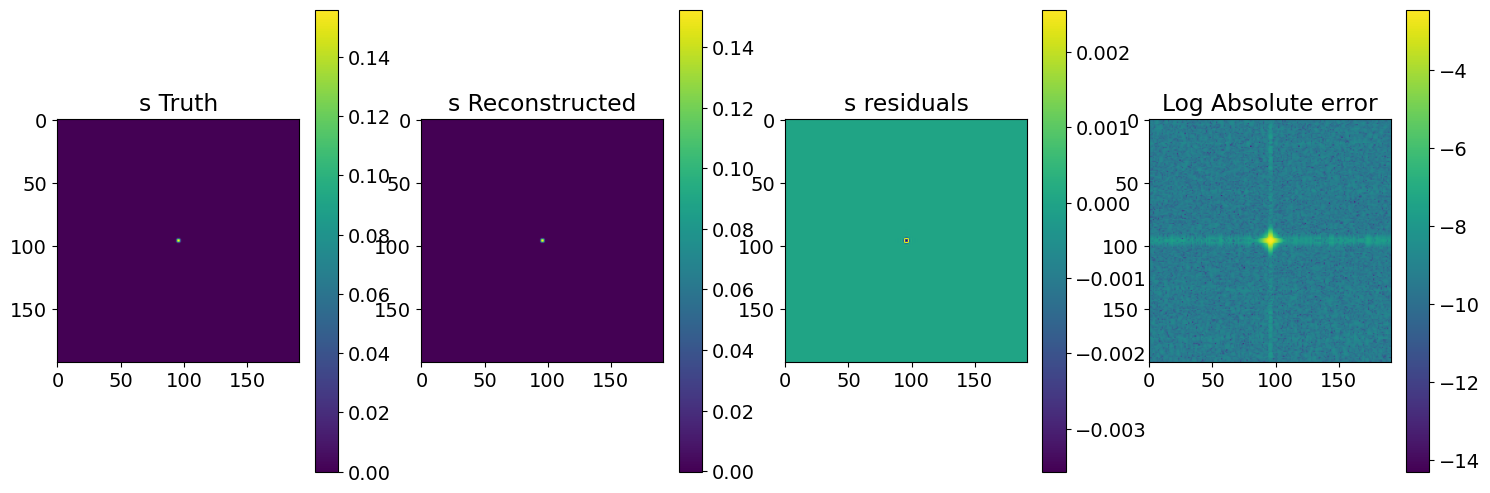

Max error / max PSF, narrow PSF: 0.022843631
MAE : 1.6864417e-06


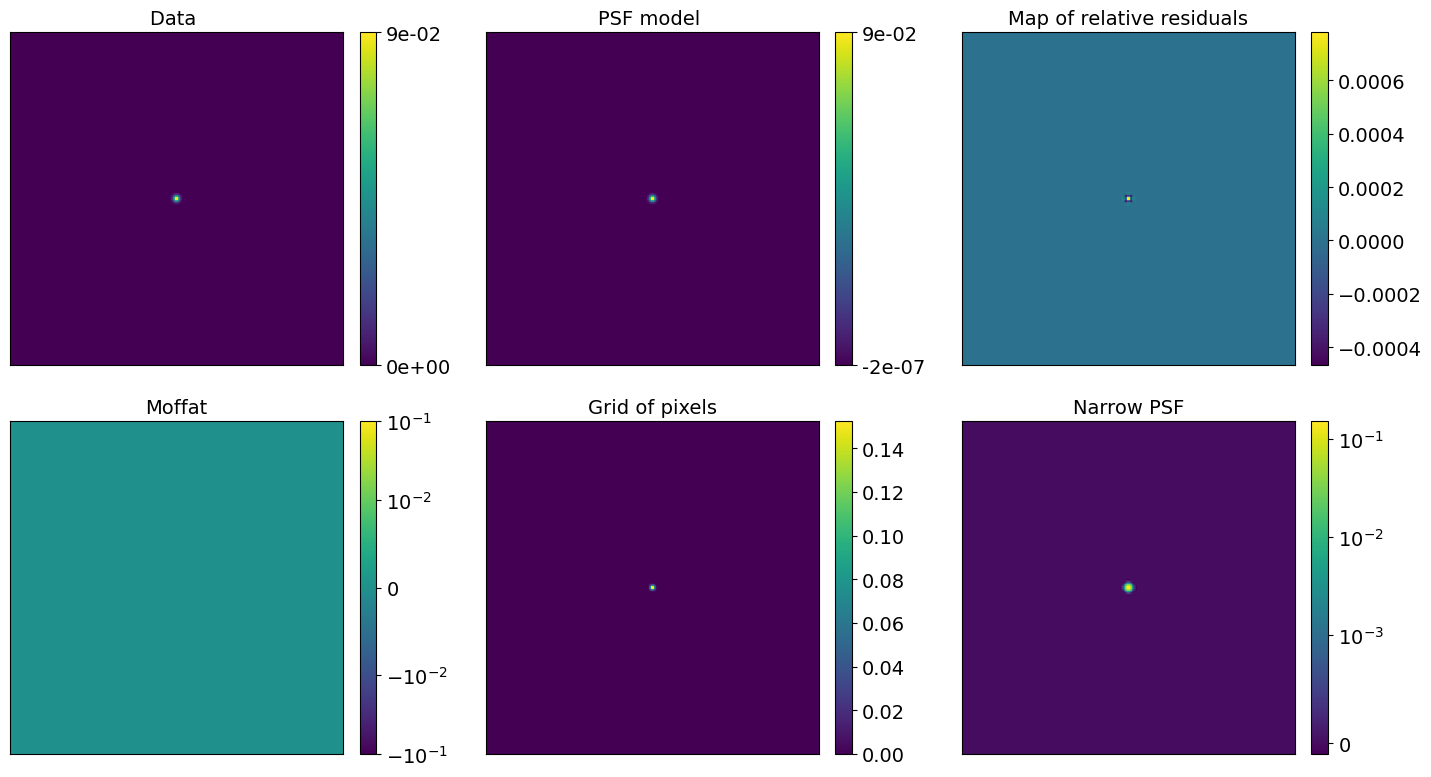

Max error / max PSF, full PSF: 0.00077880174
MAE : 2.508215e-07
#############################################
Subsampling in: 3
Original PSF size: 65
0.9999999 1.0


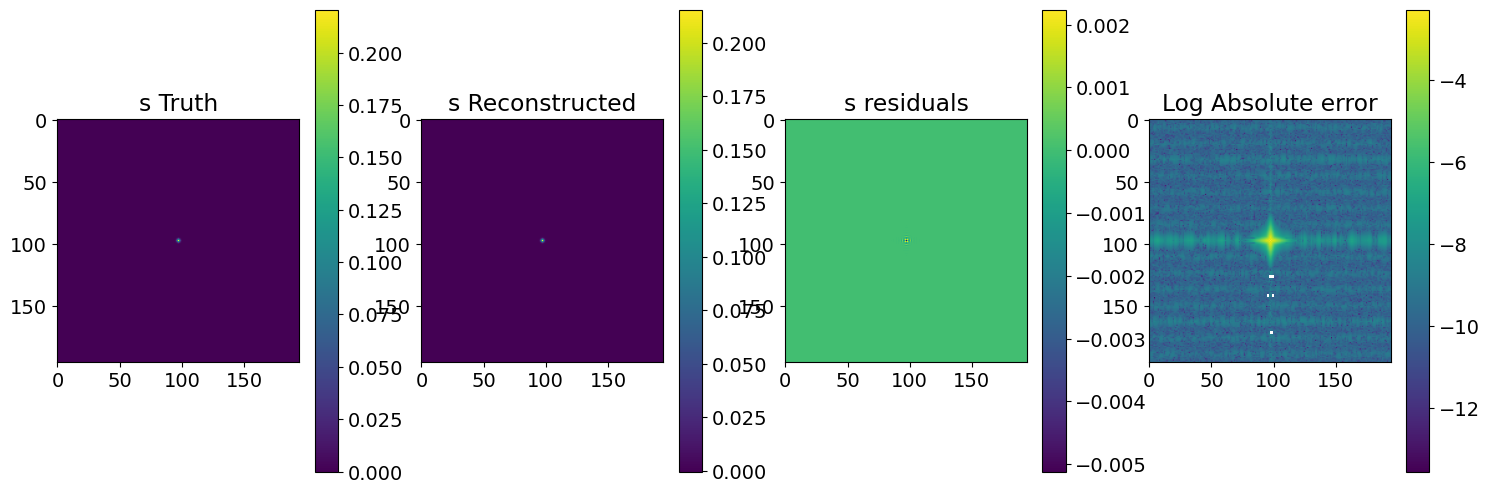

Max error / max PSF, narrow PSF: 0.02319768
MAE : 1.1651169e-06


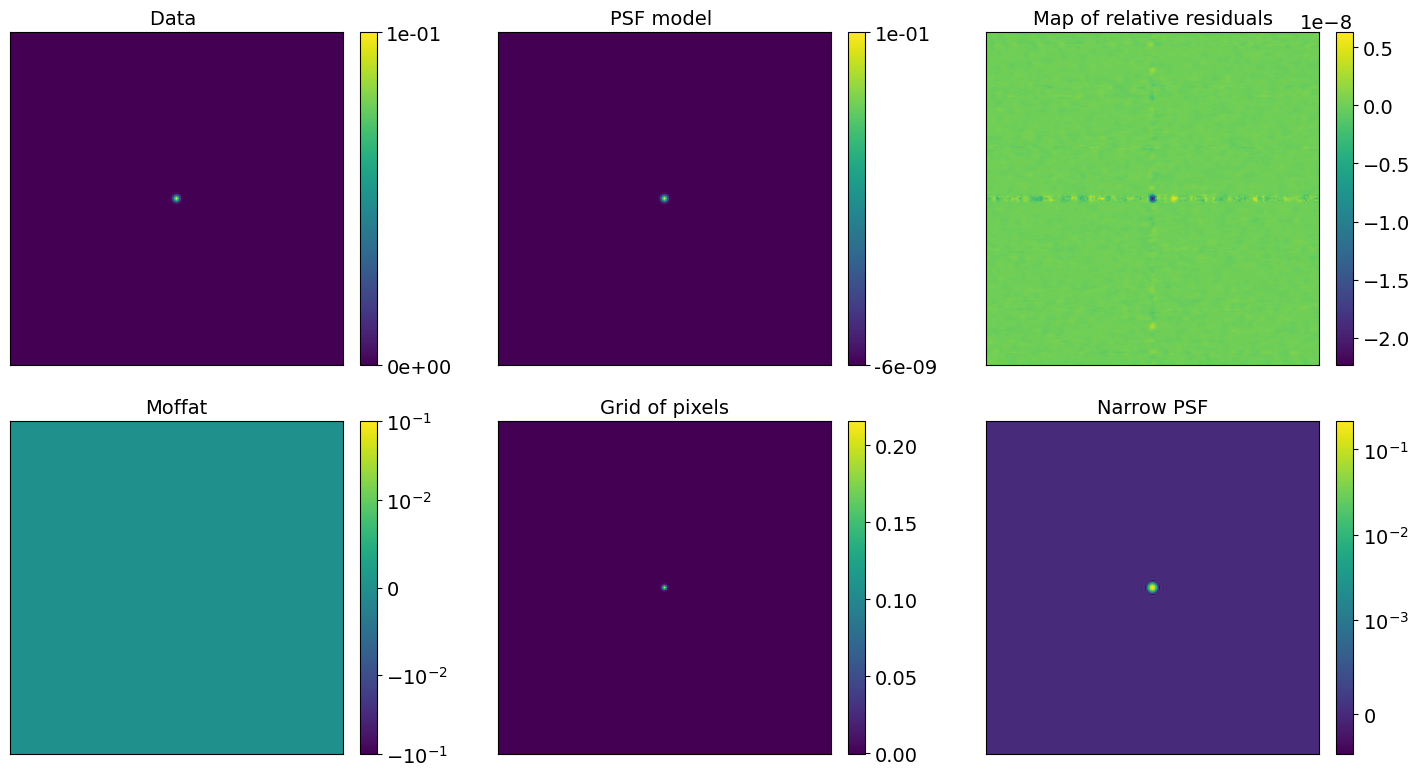

Max error / max PSF, full PSF: 4.4703484e-08
MAE : 1.7693083e-10
#############################################
Subsampling in: 4
Original PSF size: 64
1.0 0.9999998


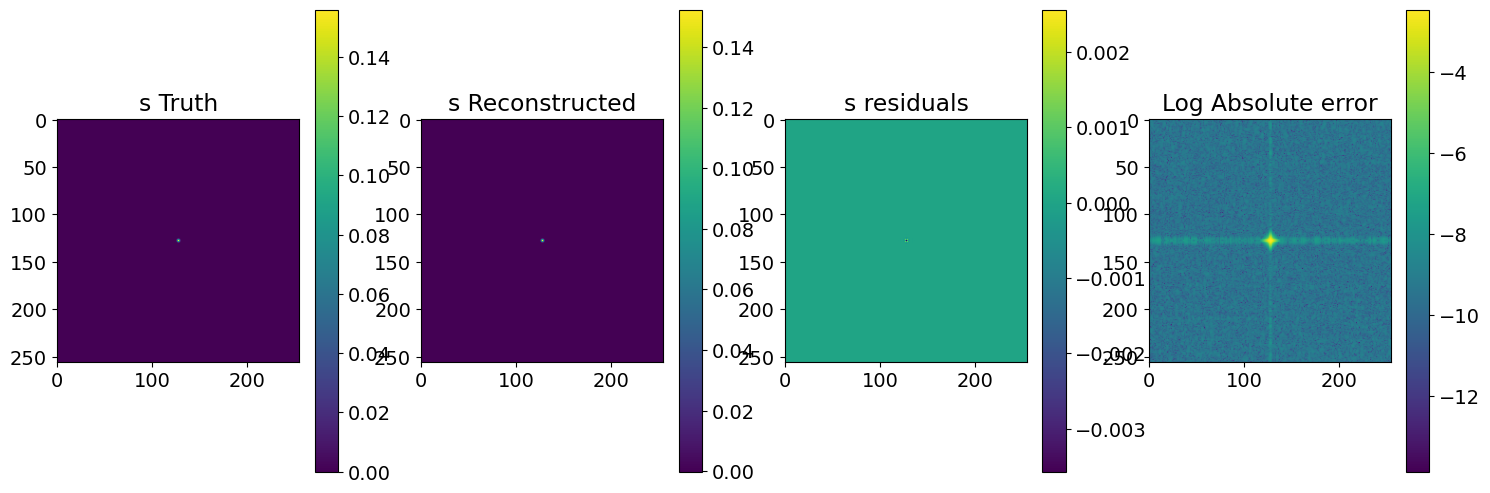

Max error / max PSF, narrow PSF: 0.022843633
MAE : 9.487992e-07


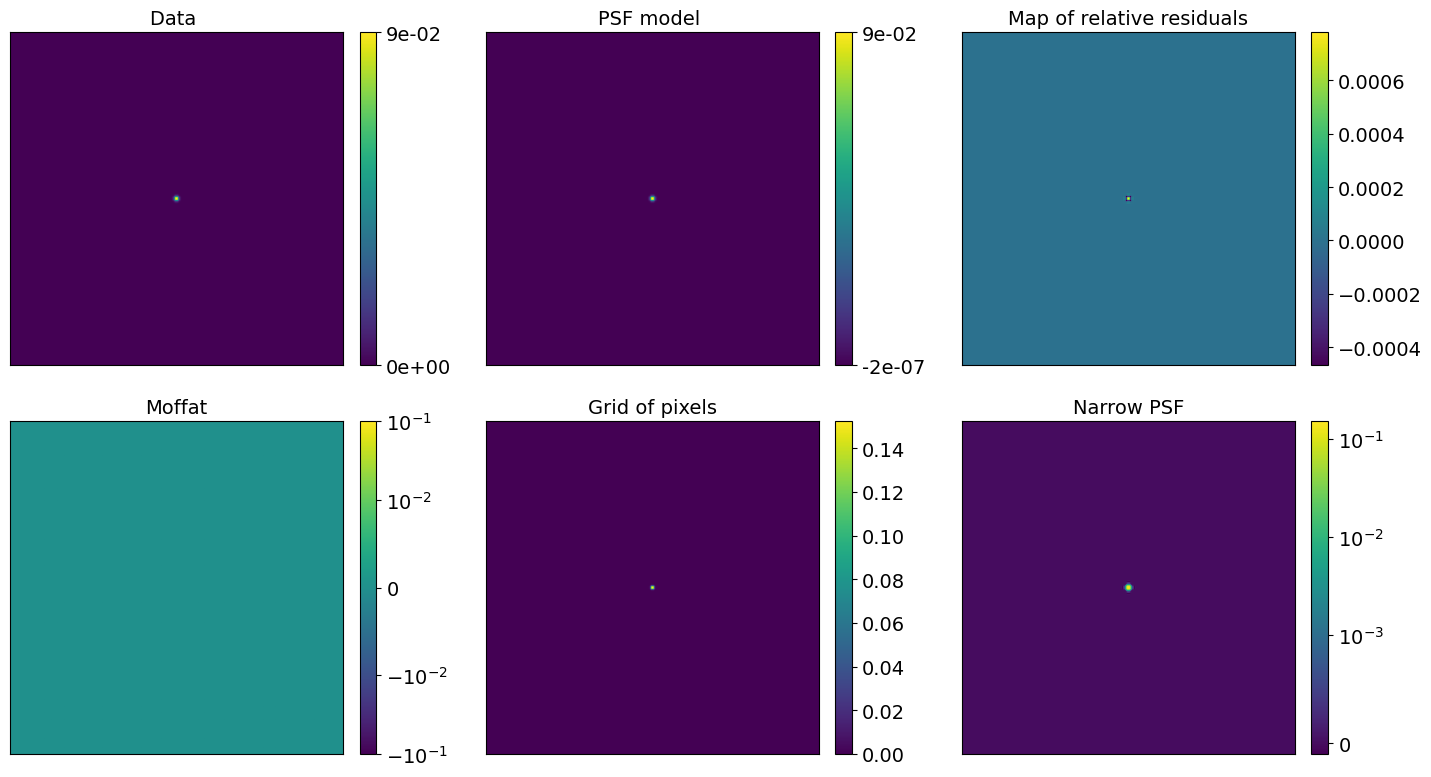

Max error / max PSF, full PSF: 0.00077874213
MAE : 1.4119075e-07
#############################################
Subsampling in: 4
Original PSF size: 65
1.0000002 0.99999976


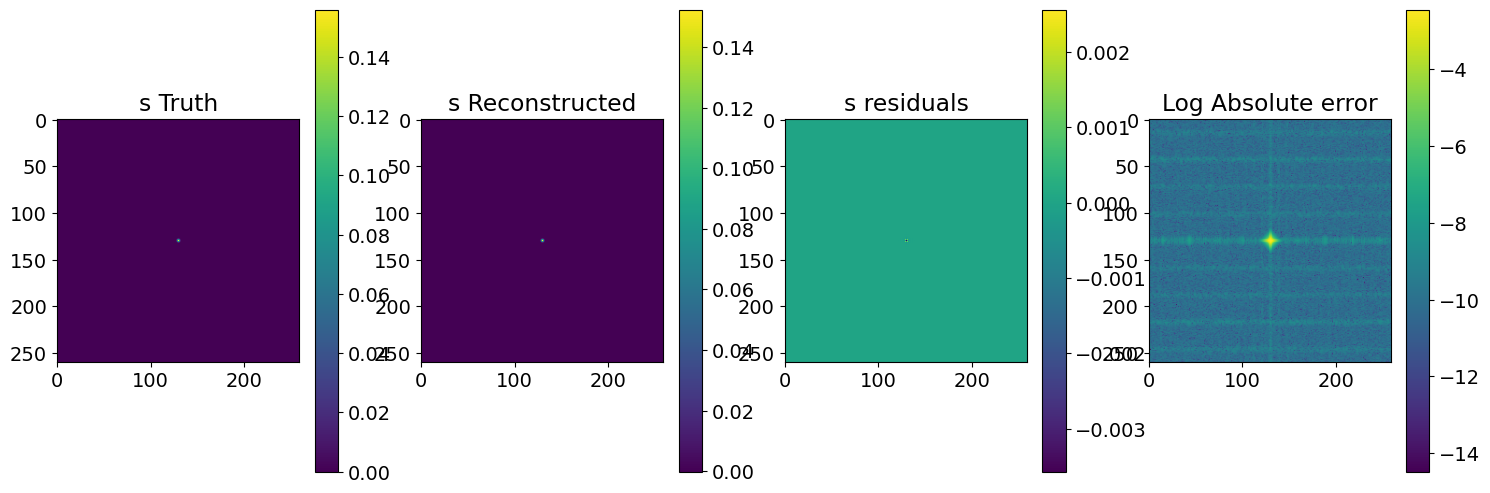

Max error / max PSF, narrow PSF: 0.022843823
MAE : 9.1942246e-07


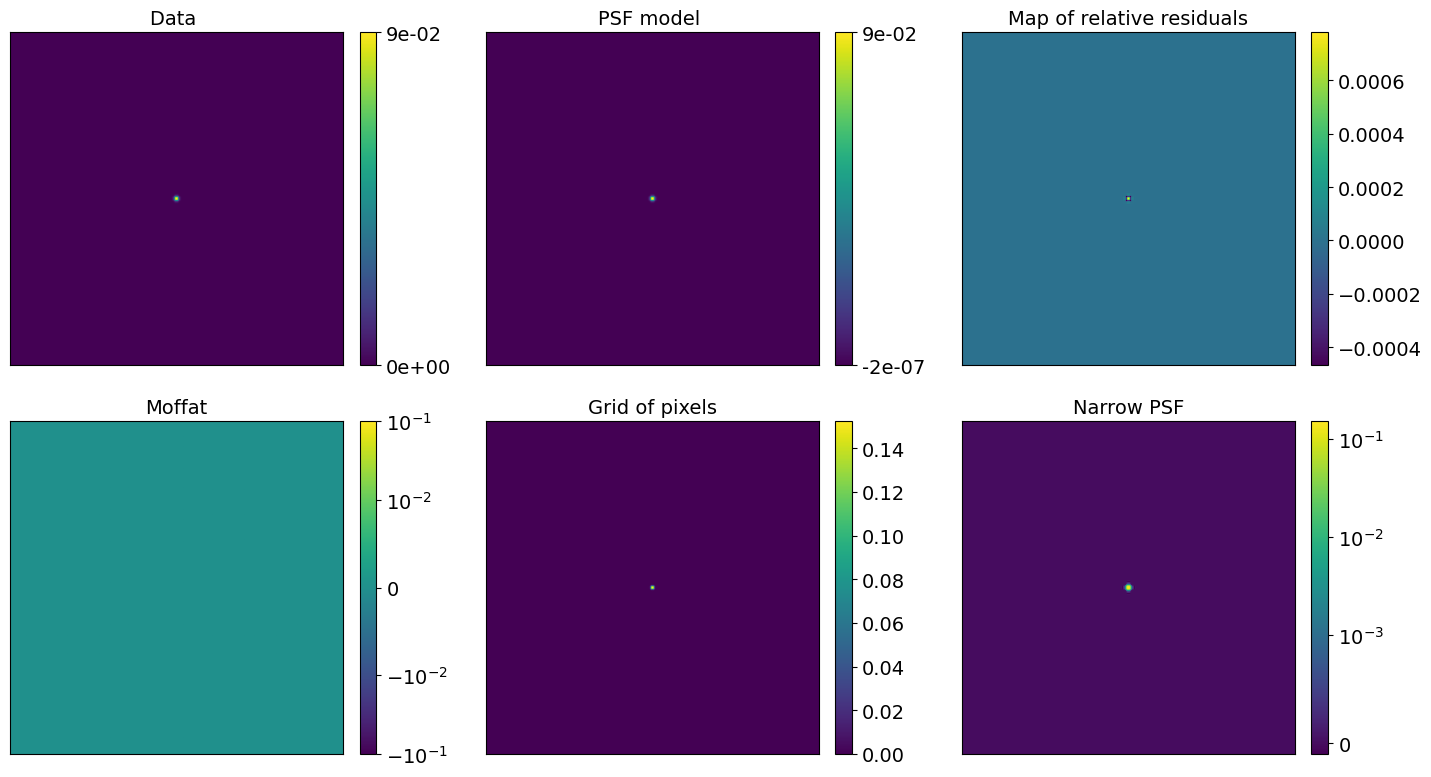

Max error / max PSF, full PSF: 0.00077877194
MAE : 1.367856e-07
#############################################
Subsampling in: 5
Original PSF size: 64
1.0000001 0.9999998


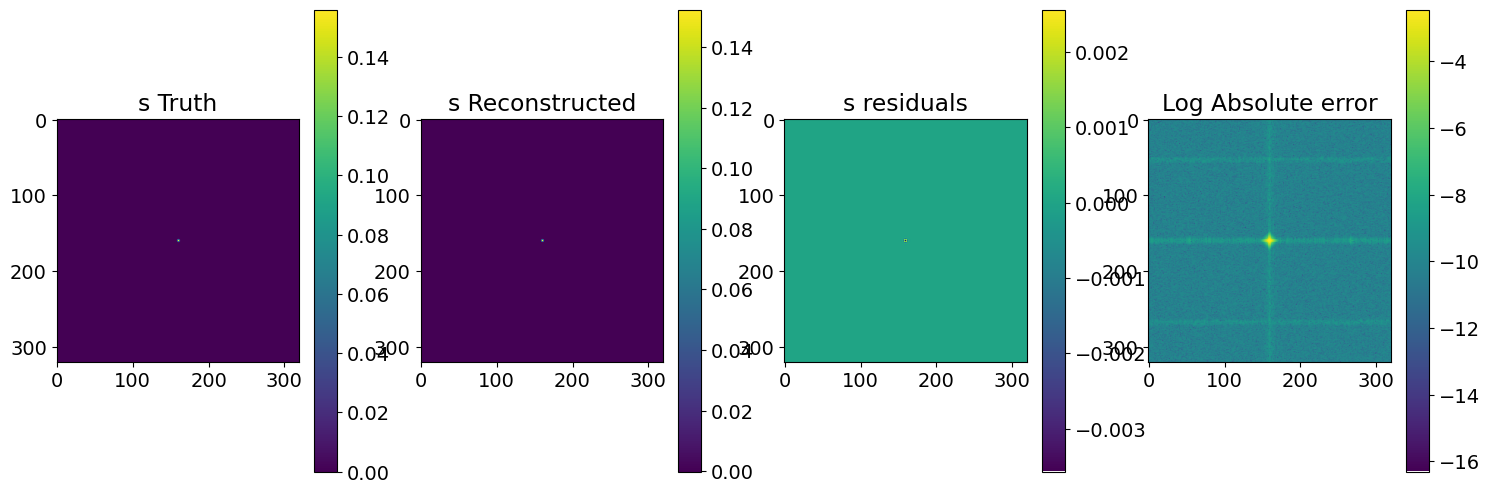

Max error / max PSF, narrow PSF: 0.022843441
MAE : 6.0697533e-07


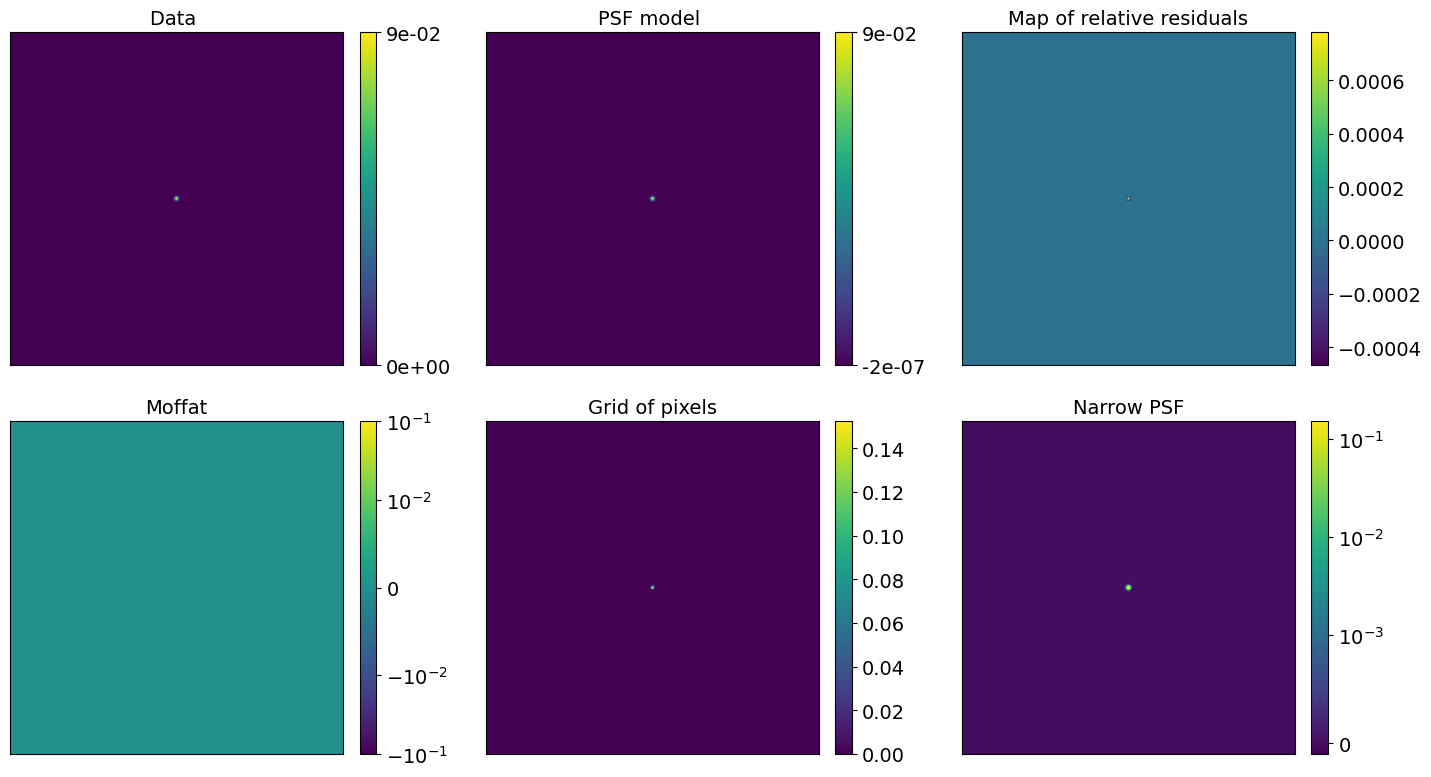

Max error / max PSF, full PSF: 0.0007787794
MAE : 9.03184e-08
#############################################
Subsampling in: 5
Original PSF size: 65
1.0000001 1.0


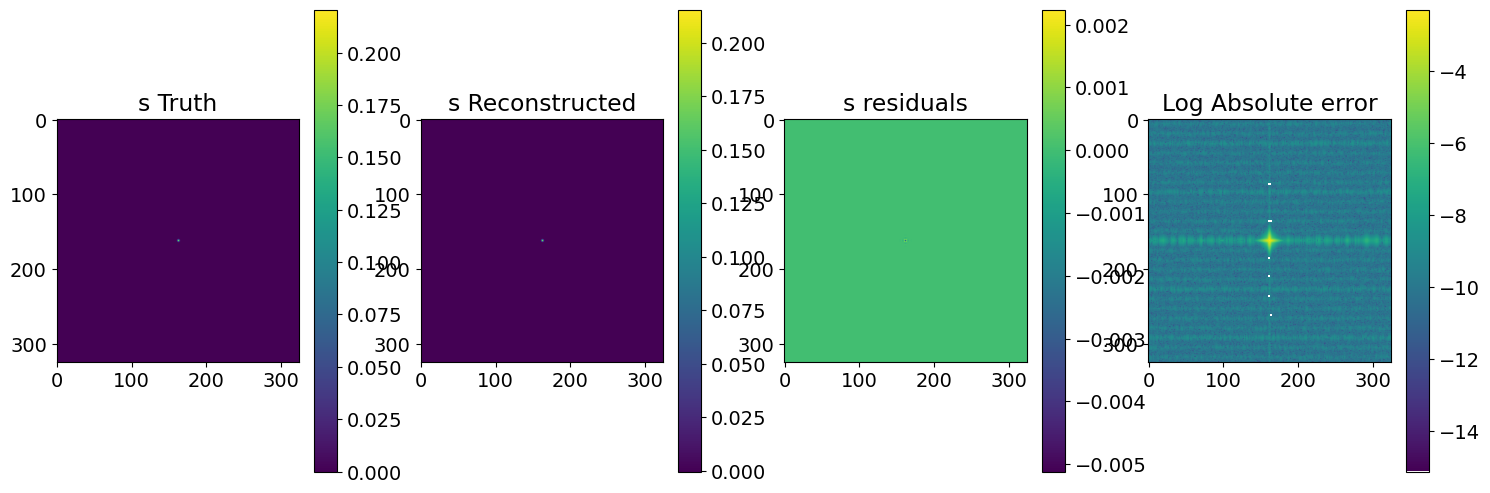

Max error / max PSF, narrow PSF: 0.023198087
MAE : 4.1959152e-07


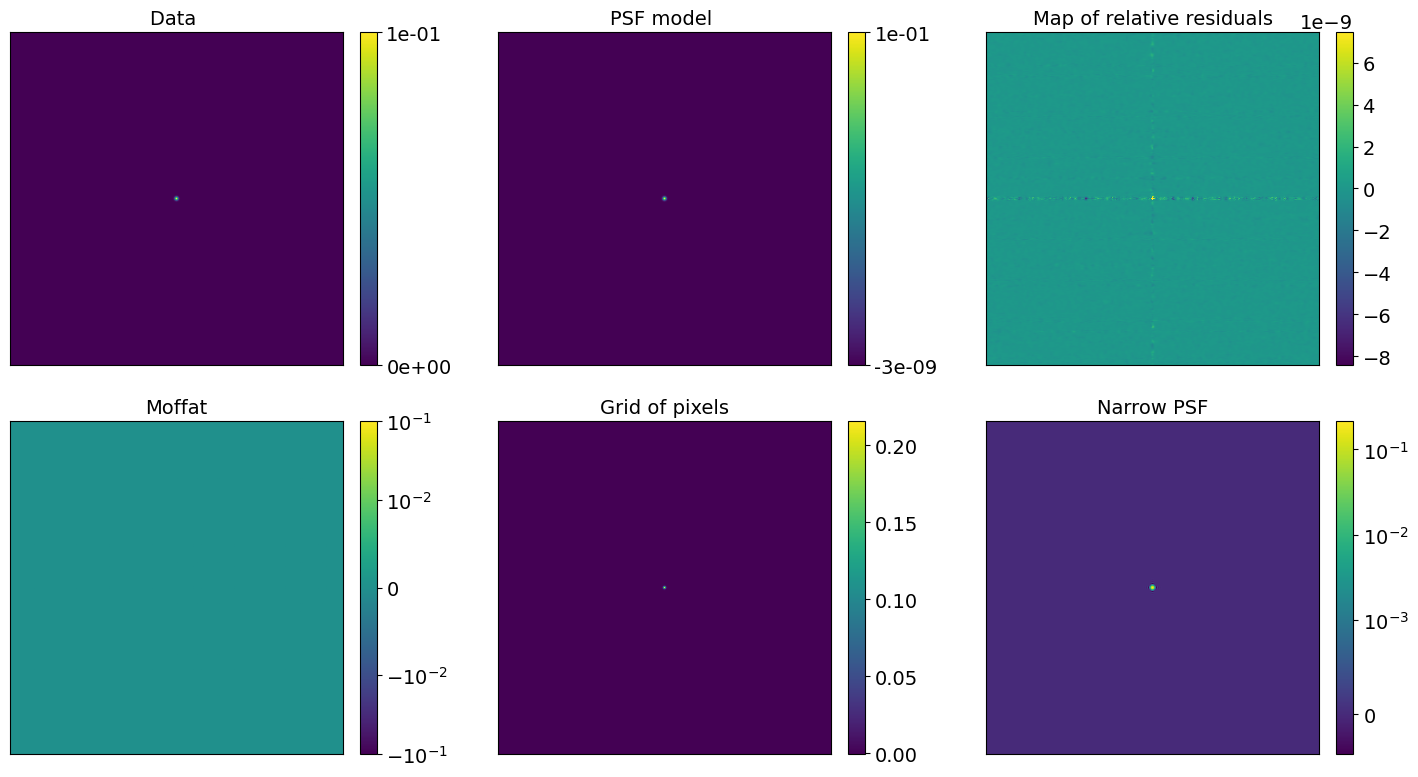

Max error / max PSF, full PSF: 1.4901161e-08
MAE : 9.9770435e-11


In [7]:
%load_ext autoreload
%autoreload 2

subsampling_ins = [1,2,3,4,5]
# subsampling_ins = [1]
npix_originals = [64,65]
# npix_originals = [64]

for subsampling_in in subsampling_ins:
    for npix_original in npix_originals:
        print('#############################################')
        print('Subsampling in:', subsampling_in)
        print('Original PSF size:', npix_original)

        subsampling_out = subsampling_in
        npsf_in = npix_original * subsampling_in
        npsf_out = npix_original * subsampling_out

        sigma_narrowpsf = fwhm2sigma(2)
        sigma_gaussian = fwhm2sigma(2)
        sigma_fullpsf = fwhm2sigma(np.sqrt(2**2 + 2**2))

        x_in, y_in = make_grid(numPix=npsf_in, deltapix=1.)
        x_out, y_out = make_grid(numPix=npsf_out, deltapix=1.)

        PSF_model = gaussian_function(
                x=x_in, y=y_in,
                amp=1, sigma_x=sigma_fullpsf,
                sigma_y=sigma_fullpsf,
                center_x=0,
                center_y=0,
            ).reshape(npsf_in, npsf_in)

        narrow_psf_truth = gaussian_function(
                x=x_out, y=y_out,
                amp=1, sigma_x=sigma_narrowpsf,
                sigma_y=sigma_narrowpsf,
                center_x=0,
                center_y=0,
            ).reshape(npsf_out, npsf_out)


        narrow_psf_reconstructed = narrow_psf_from_model(PSF_model, subsampling_in, subsampling_out, mode='fourier_division')
        print(np.sum(narrow_psf_reconstructed), np.sum(narrow_psf_truth))

        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        fig.colorbar(axes[0].imshow(narrow_psf_truth))
        axes[0].set_title('s Truth')
        fig.colorbar(axes[1].imshow(narrow_psf_reconstructed))
        axes[1].set_title('s Reconstructed')
        fig.colorbar(axes[2].imshow(narrow_psf_reconstructed - narrow_psf_truth))
        axes[2].set_title('s residuals')
        fig.colorbar(axes[3].imshow(np.log10(np.abs(narrow_psf_reconstructed - narrow_psf_truth))))
        axes[3].set_title('Log Absolute error')
        plt.show()

        assert np.allclose(narrow_psf_reconstructed, narrow_psf_truth, atol=1e-2)
        assert np.max(np.abs(narrow_psf_reconstructed - narrow_psf_truth))/np.max(narrow_psf_truth) < 0.03 

        print('Max error / max PSF, narrow PSF:', np.max(np.abs(narrow_psf_reconstructed - narrow_psf_truth))/np.max(narrow_psf_truth))
        print('MAE :', np.mean(np.abs(narrow_psf_reconstructed - narrow_psf_truth)))


        # build the PFS class and check that the convolution works
        model = PSF(image_size=npsf_in, upsampling_factor=1, number_of_sources=1, include_moffat=False)
        kwargs, _, _, _ = model.smart_guess(PSF_model[np.newaxis, :, :])
        kwargs['kwargs_moffat']['C'] = 0.
        kwargs['kwargs_gaussian']['a'] = np.array([1.])
        kwargs['kwargs_gaussian']['x0'] = np.array([0.])
        kwargs['kwargs_gaussian']['y0'] = np.array([0.])
        kwargs['kwargs_background']['background'] = narrow_psf_reconstructed.ravel()
        sigma2 = np.ones_like(PSF_model[np.newaxis, :, :])
        fig2 = single_PSF_plot(model, PSF_model[np.newaxis, :, :], sigma2, kwargs)
        plt.show()

        plt.close('all')

        full_PFS_reconstructed = model.get_full_psf(**kwargs)

        print('Max error / max PSF, full PSF:', np.max(np.abs(full_PFS_reconstructed - PSF_model)))
        print('MAE :', np.mean(np.abs(full_PFS_reconstructed - PSF_model)))
        assert np.allclose(full_PFS_reconstructed, PSF_model, atol=1e-3)
        assert np.max(np.abs(full_PFS_reconstructed - PSF_model))/np.max(PSF_model) < 0.01

__Remarks__ : Numerical error are higher when using even kernel size. Consider using an odd number of pixel in your kernel, i.e. `npix` * `subsamplingfactor` is odd. 

Overall, the reconstructed narrow PSF has an MAE better than 1e-5 and a max error per pixel 3%

# Obtaining `s` at a higher resolution than your input model

This is not recommended but you might want to upsample your PSF model. As you will see, this leads to important error, as the subpixel information is simply not contained in your model. 
Using natural stars in the field of view would probably be a better option in this case.  

#############################################
Subsampling in: 1 Increase factor: 2
Original PSF size: 64
Subsampling out: 2
1.0000001 0.9999999
(128, 128) (128, 128)


/Users/martin/Desktop/modules/starred/starred/procedures/psf_routines.py:536: UserWarning: The desired subsampling factor is higher than the input subsampling factor of the PSF model. This is a very ill-posed problem because I will need to interpolate your PSF model.
  warnings.warn(


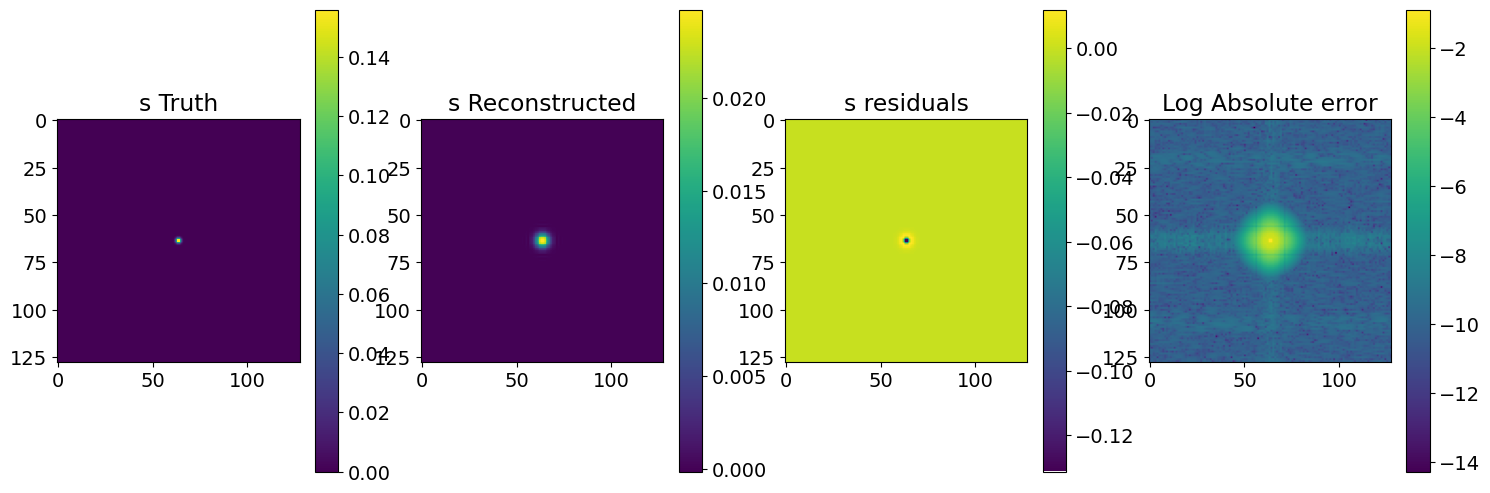

Max error / max PSF: 0.84117657
MAE : 8.0440375e-05


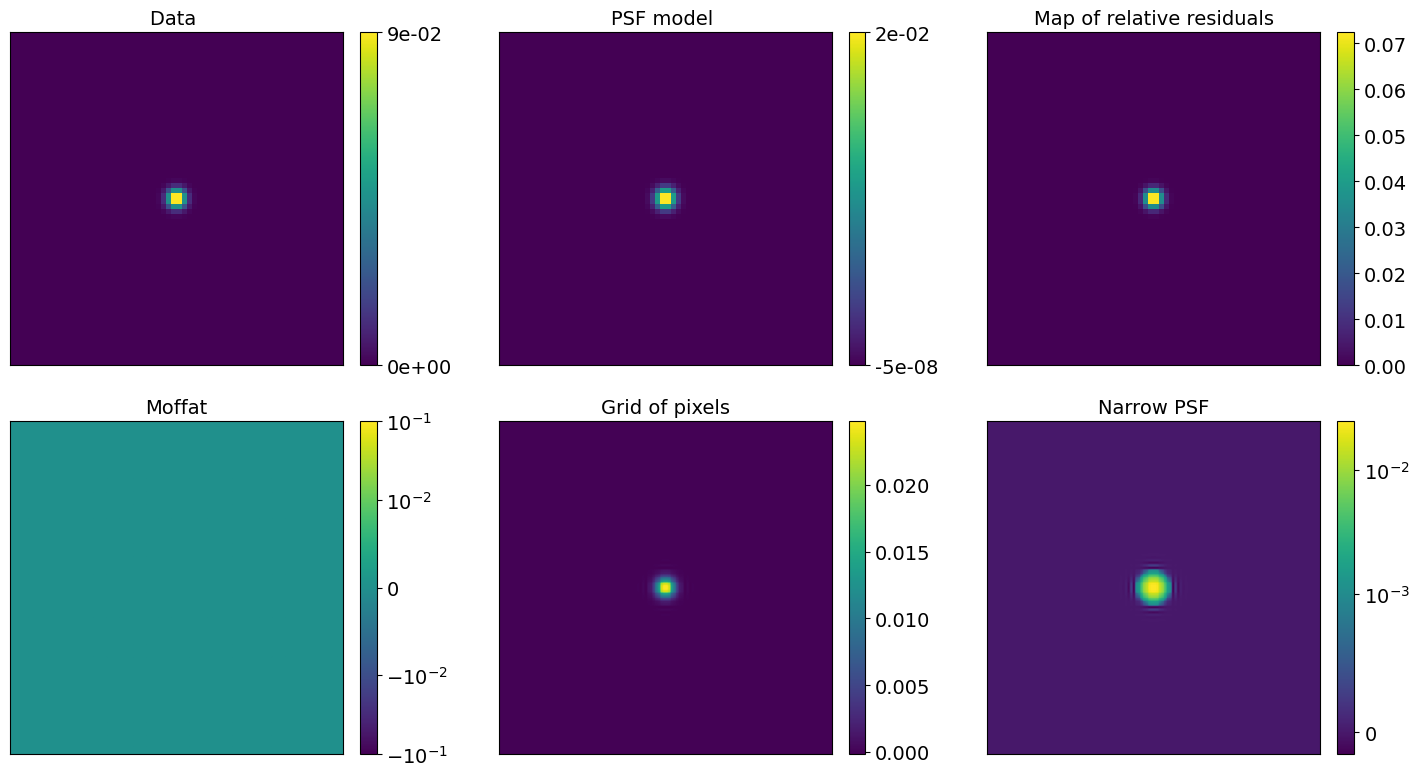

Max error / max PSF, full PSF: 0.122640274
MAE : 2.8214496e-05
#############################################
Subsampling in: 1 Increase factor: 2
Original PSF size: 65
Subsampling out: 2
1.0 0.9999998
(130, 130) (130, 130)


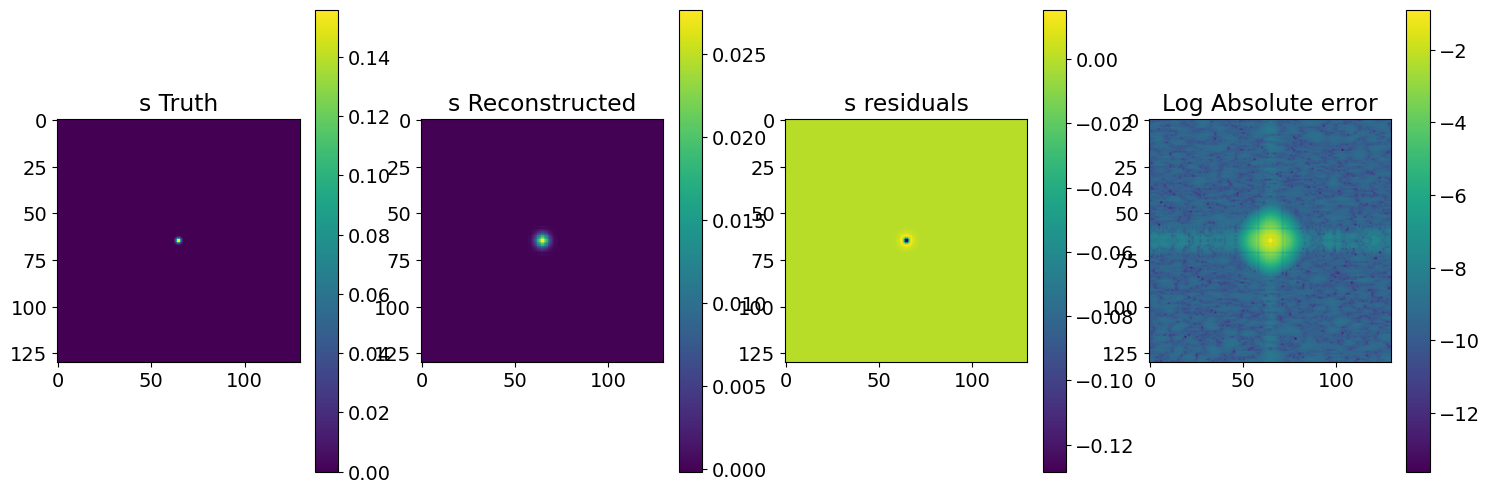

Max error / max PSF: 0.8226769
MAE : 7.853121e-05


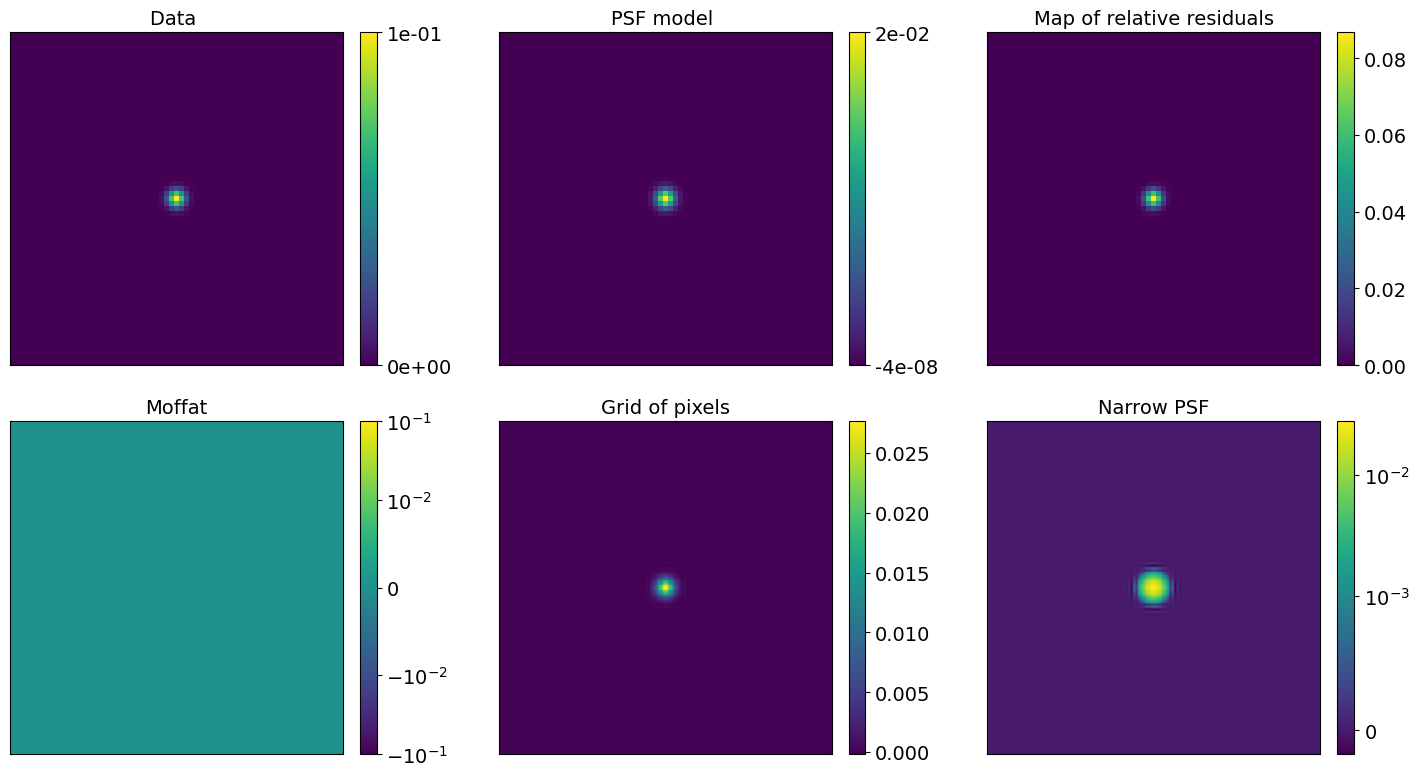

Max error / max PSF, full PSF: 0.14305195
MAE : 2.8428089e-05
#############################################
Subsampling in: 1 Increase factor: 3
Original PSF size: 64
Subsampling out: 3
0.9999998 0.9999998
(192, 192) (192, 192)


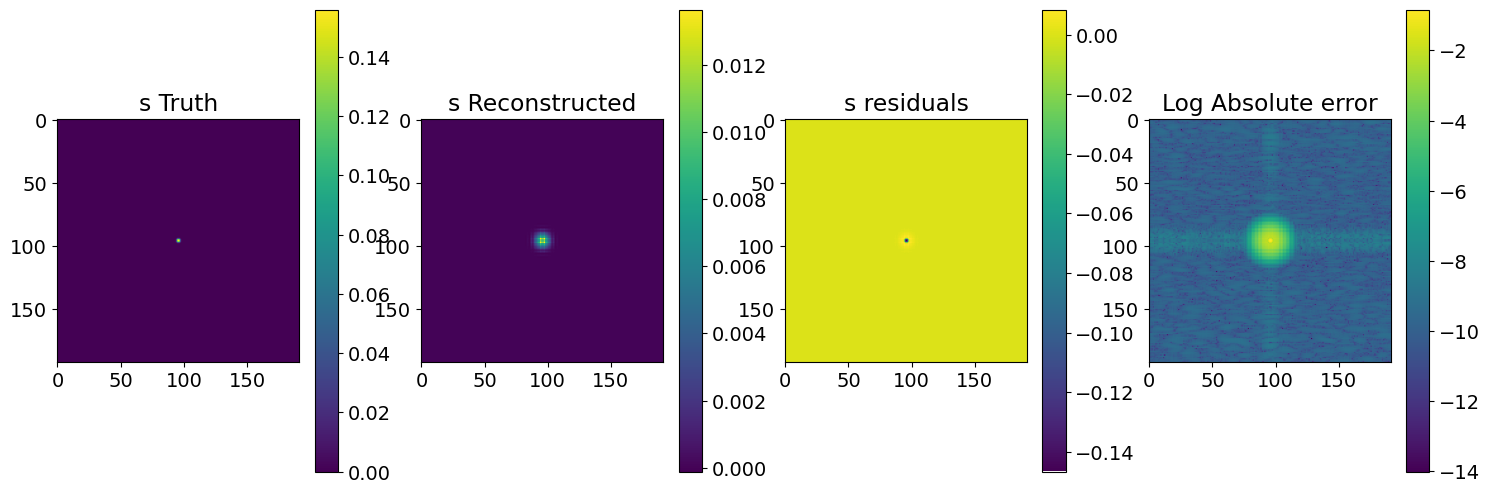

Max error / max PSF: 0.9395034
MAE : 4.4071647e-05


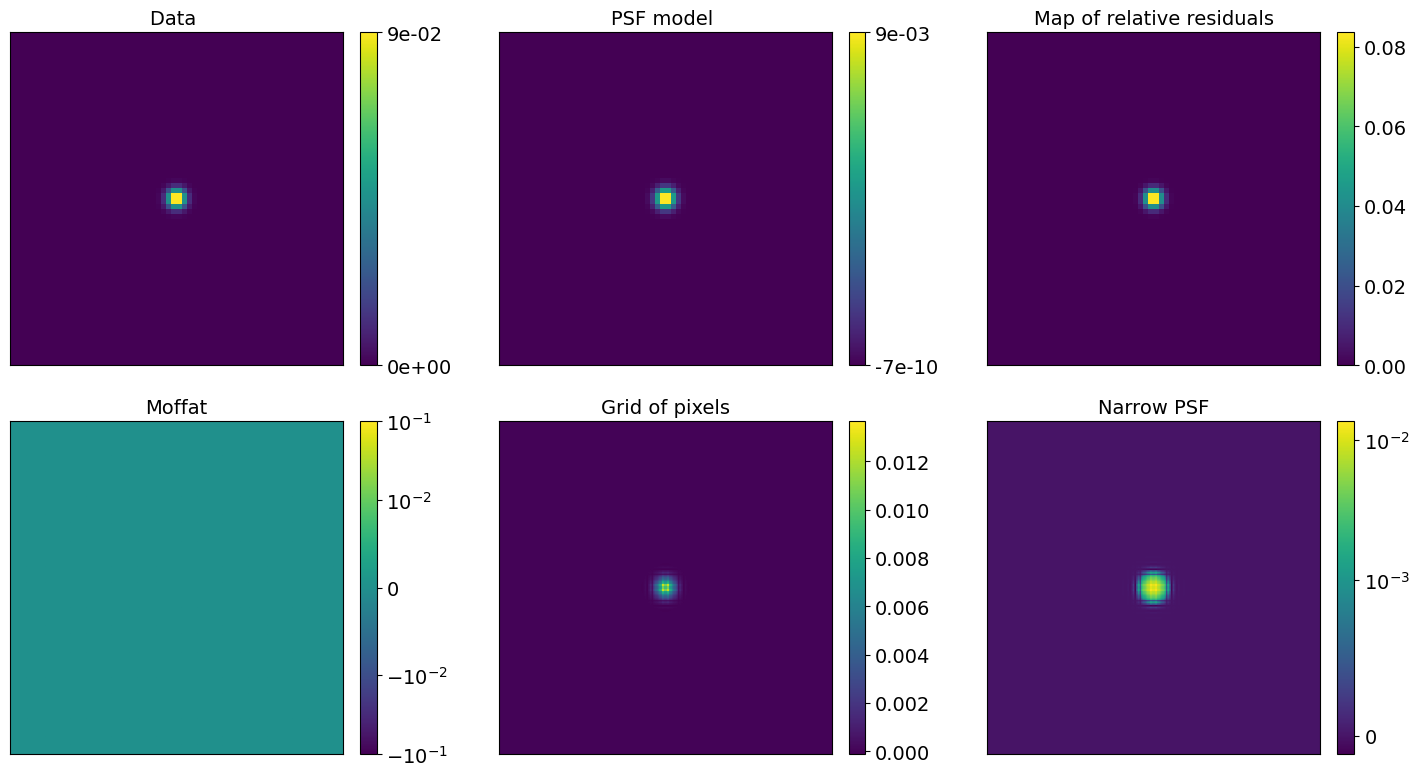

Max error / max PSF, full PSF: 0.10706275
MAE : 2.4755871e-05
#############################################
Subsampling in: 1 Increase factor: 3
Original PSF size: 65
Subsampling out: 3
0.99999964 1.0
(195, 195) (195, 195)


/var/folders/k5/9nxb2fnj4zsbb1nrtpvbf8000000gn/T/ipykernel_82932/2876118810.py:56: RuntimeWarning: divide by zero encountered in log10
  fig.colorbar(axes[3].imshow(np.log10(np.abs(narrow_psf_reconstructed - narrow_psf_truth))))


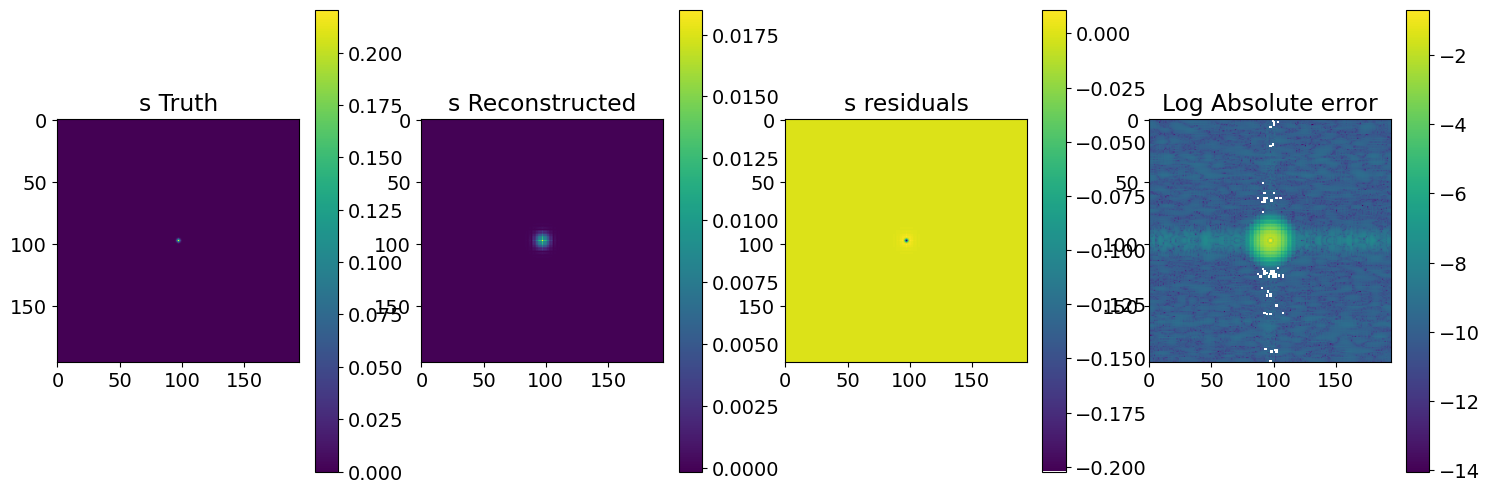

Max error / max PSF: 0.9161072
MAE : 4.1889518e-05


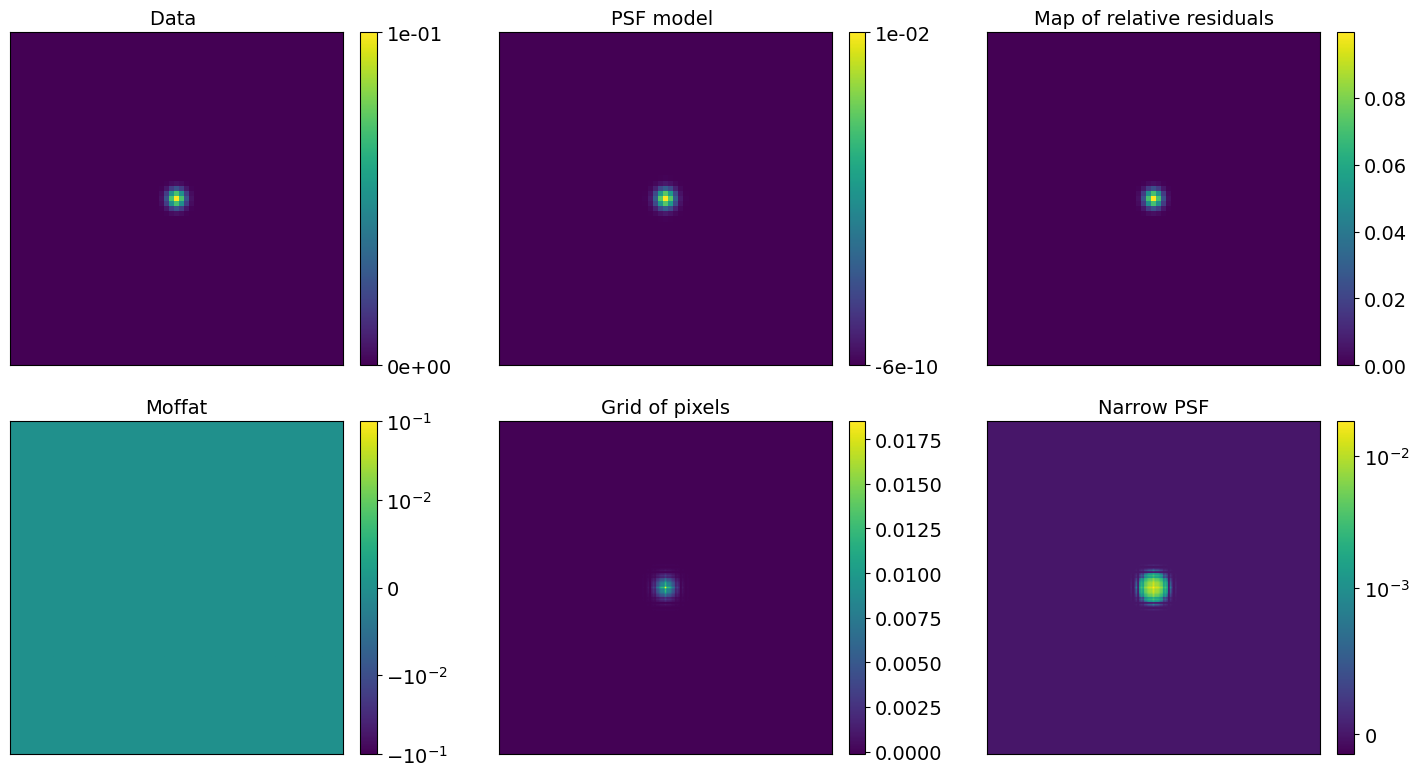

Max error / max PSF, full PSF: 0.12593818
MAE : 2.5074436e-05


In [18]:
#checking if the convolution returns the correct thing: 

subsampling_ins = [1]
increase_factors = [2,3]
# subsampling_ins = [1]
npix_originals = [64,65]
# npix_originals = [64]

for subsampling_in in subsampling_ins:
    for increase_factor in increase_factors:
        for npix_original in npix_originals:
            print('#############################################')
            print('Subsampling in:', subsampling_in, 'Increase factor:', increase_factor)
            print('Original PSF size:', npix_original)

            subsampling_out = increase_factor * subsampling_in
            print('Subsampling out:', subsampling_out)  
            npsf_in = npix_original * subsampling_in
            npsf_out = npix_original * subsampling_out

            sigma_narrowpsf = fwhm2sigma(2)
            sigma_gaussian = fwhm2sigma(2)
            sigma_fullpsf = fwhm2sigma(np.sqrt(2**2 + 2**2))

            x_in, y_in = make_grid(numPix=npsf_in, deltapix=1.)
            x_out, y_out = make_grid(numPix=npsf_out, deltapix=1.)

            PSF_model = gaussian_function(
                    x=x_in, y=y_in,
                    amp=1, sigma_x=sigma_fullpsf,
                    sigma_y=sigma_fullpsf,
                    center_x=0,
                    center_y=0,
                ).reshape(npsf_in, npsf_in)

            narrow_psf_truth = gaussian_function(
                    x=x_out, y=y_out,
                    amp=1, sigma_x=sigma_narrowpsf,
                    sigma_y=sigma_narrowpsf,
                    center_x=0,
                    center_y=0,
                ).reshape(npsf_out, npsf_out)


            narrow_psf_reconstructed = narrow_psf_from_model(PSF_model, subsampling_in, subsampling_out, mode='fourier_division')
            print(np.sum(narrow_psf_reconstructed), np.sum(narrow_psf_truth))
            print(np.shape(narrow_psf_reconstructed), np.shape(narrow_psf_truth))

            fig, axes = plt.subplots(1, 4, figsize=(18, 6))
            fig.colorbar(axes[0].imshow(narrow_psf_truth))
            axes[0].set_title('s Truth')
            fig.colorbar(axes[1].imshow(narrow_psf_reconstructed))
            axes[1].set_title('s Reconstructed')
            fig.colorbar(axes[2].imshow(narrow_psf_reconstructed - narrow_psf_truth))
            axes[2].set_title('s residuals')
            fig.colorbar(axes[3].imshow(np.log10(np.abs(narrow_psf_reconstructed - narrow_psf_truth))))
            axes[3].set_title('Log Absolute error')
            plt.show()

            # assert np.allclose(narrow_psf_reconstructed, narrow_psf_truth, atol=1e-1)

            print('Max error / max PSF:', np.max(np.abs(narrow_psf_reconstructed - narrow_psf_truth))/np.max(narrow_psf_truth))
            print('MAE :', np.mean(np.abs(narrow_psf_reconstructed - narrow_psf_truth)))


            # build the PFS class and check that the convolution works
            model = PSF(image_size=npsf_in, upsampling_factor=increase_factor, number_of_sources=1, include_moffat=False)
            kwargs, _, _, _ = model.smart_guess(PSF_model[np.newaxis, :, :])
            kwargs['kwargs_moffat']['C'] = 0.
            kwargs['kwargs_gaussian']['a'] = np.array([1.])
            kwargs['kwargs_gaussian']['x0'] = np.array([0.])
            kwargs['kwargs_gaussian']['y0'] = np.array([0.])
            kwargs['kwargs_background']['background'] = narrow_psf_reconstructed.ravel()
            sigma2 = np.ones_like(PSF_model[np.newaxis, :, :])
            fig2 = single_PSF_plot(model, PSF_model[np.newaxis, :, :], sigma2, kwargs)
            plt.show()

            plt.close('all')

            full_PFS_reconstructed = model.get_full_psf(**kwargs, high_res=False)

            print('Max error / max PSF, full PSF:', np.max(np.abs(full_PFS_reconstructed - PSF_model))/ np.max(PSF_model))
            print('MAE :', np.mean(np.abs(full_PFS_reconstructed - PSF_model)))
            assert np.allclose(full_PFS_reconstructed, PSF_model, atol=1e-1)
            assert np.max(np.abs(full_PFS_reconstructed - PSF_model)) / np.max(PSF_model) < 0.15

__Remarks__ :Residuals at the center are due to interpolation errors. Linear interpolation gives the best results. 

# Obtaining `s` at a lower resolution than your input model

This is not recommended either but you might want to obtain `s` at a lower resolution than your PSF model. 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
#############################################
Subsampling in: 2 Increase factor: 0.5
Original PSF size: 64
Subsampling out: 1
1.0 0.9999998
(64, 64) (64, 64)


/Users/martin/Desktop/modules/starred/starred/procedures/psf_routines.py:572: UserWarning: Are you sure you want to degrade your narrow PSF model?
  warnings.warn('Are you sure you want to degrade your narrow PSF model?')


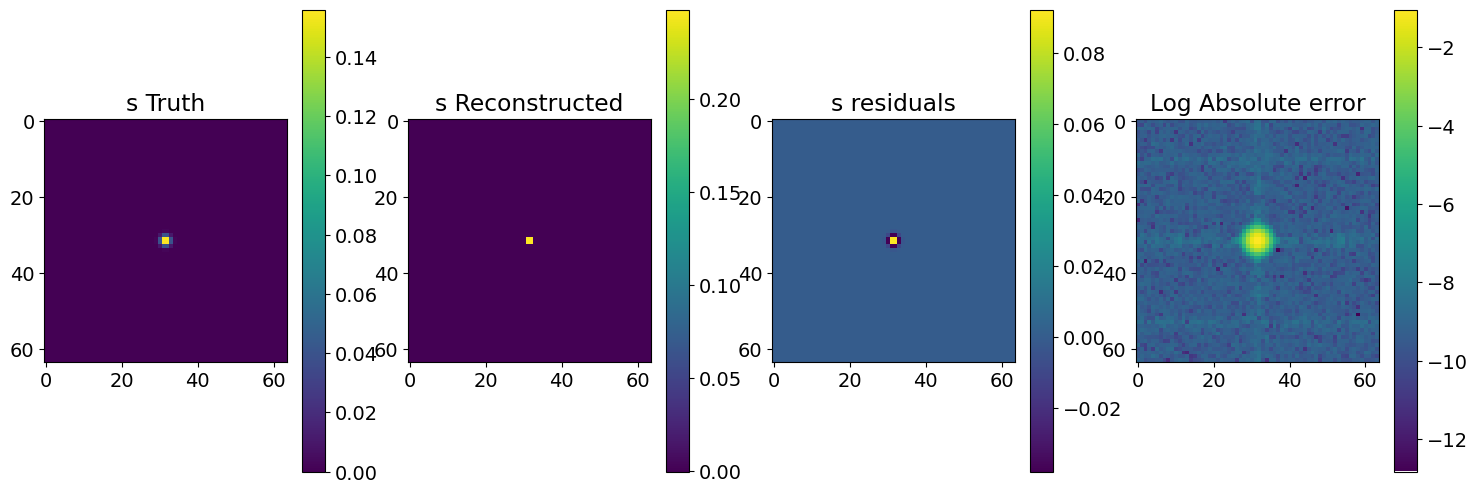

Max error / max PSF: 0.59121114
MAE : 0.0001801507


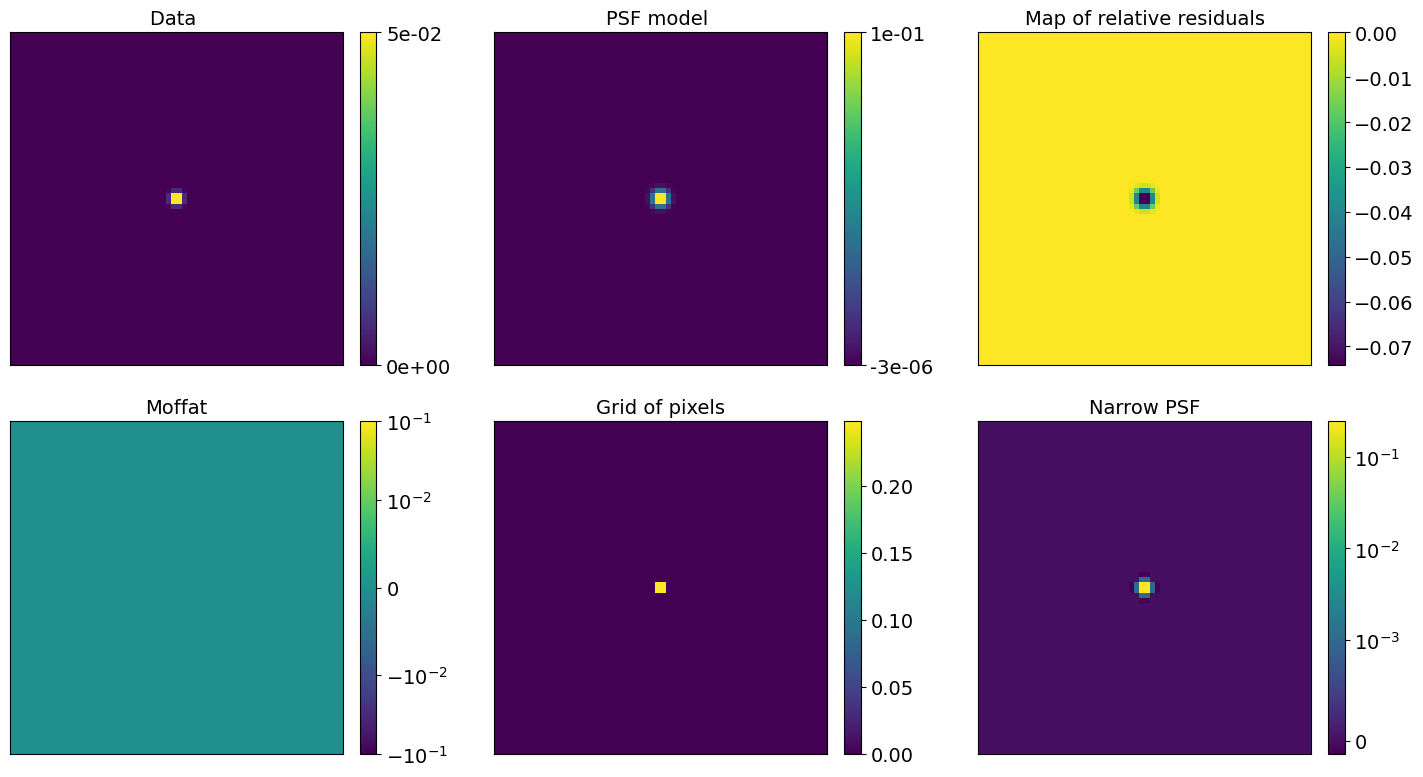

Max error / max PSF, full PSF: 1.501417
MAE : 0.00018312279
#############################################
Subsampling in: 2 Increase factor: 0.5
Original PSF size: 65
Subsampling out: 1
1.0000001 1.0
(65, 65) (65, 65)


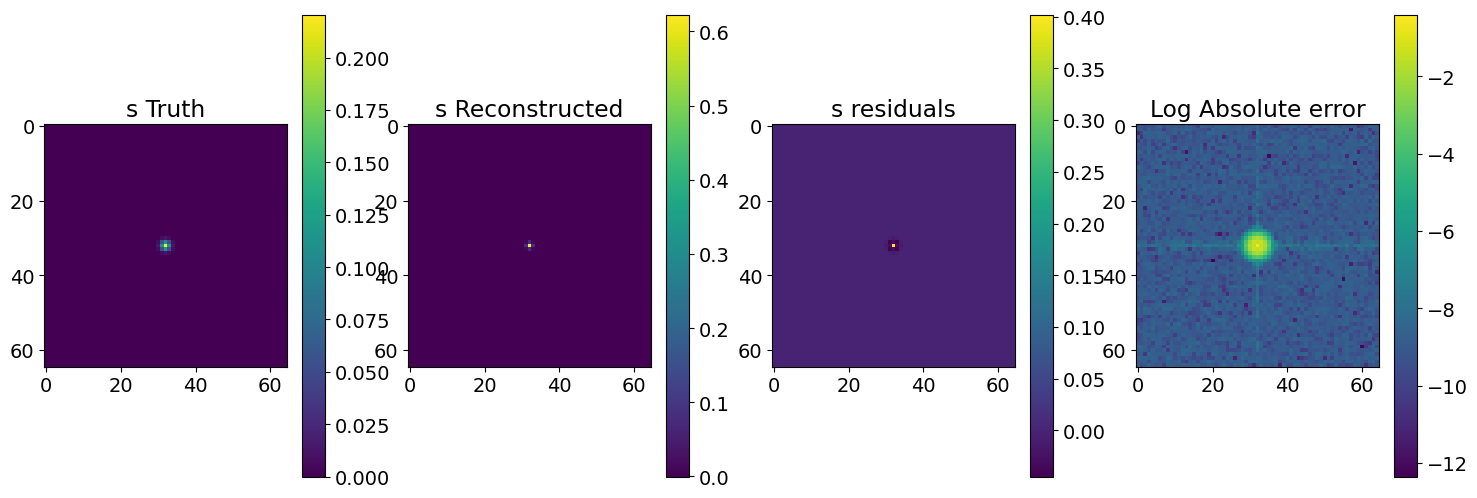

Max error / max PSF: 1.8221636
MAE : 0.00019031545


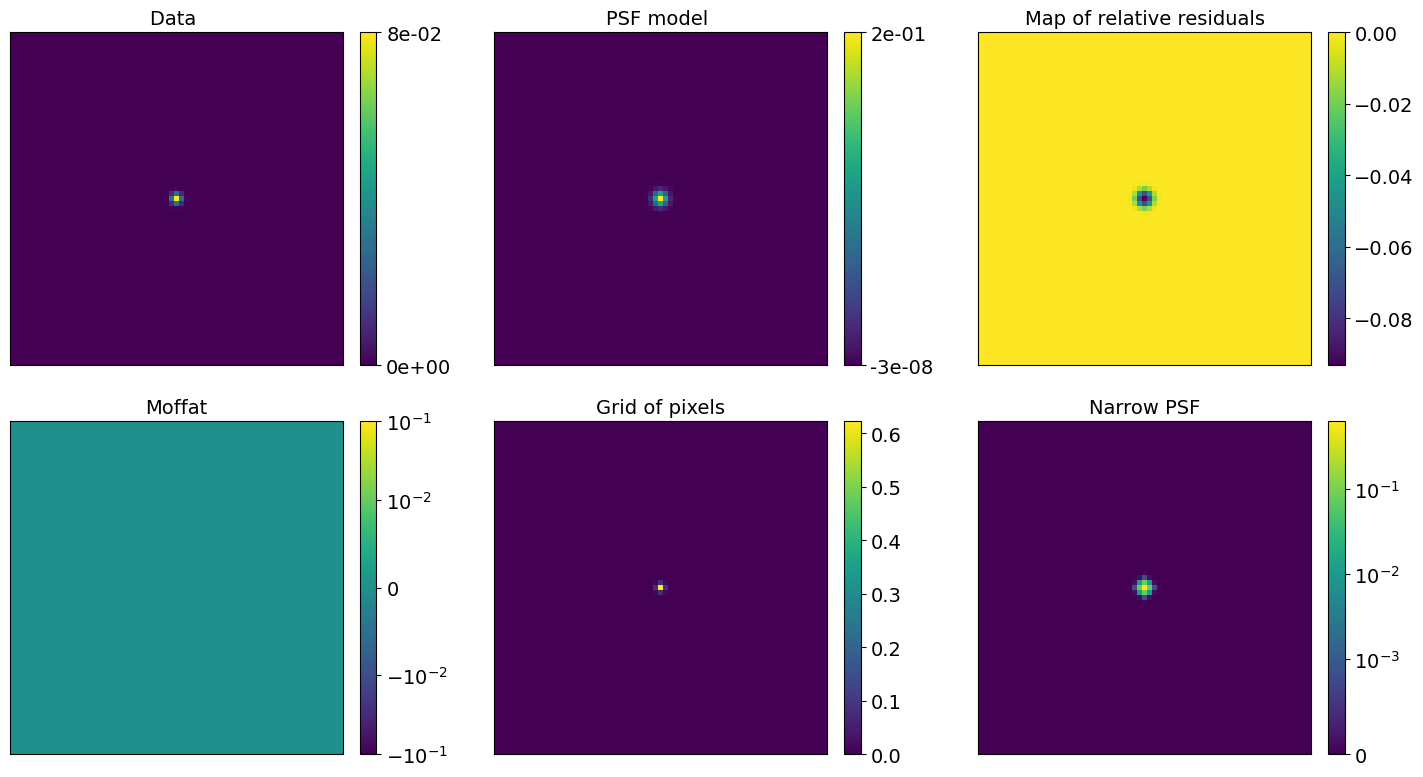

Max error / max PSF, full PSF: 1.1207485
MAE : 0.00017751553
#############################################
Subsampling in: 3 Increase factor: 0.3333333333333333
Original PSF size: 64
Subsampling out: 1
0.99999994 0.9999998
(64, 64) (64, 64)


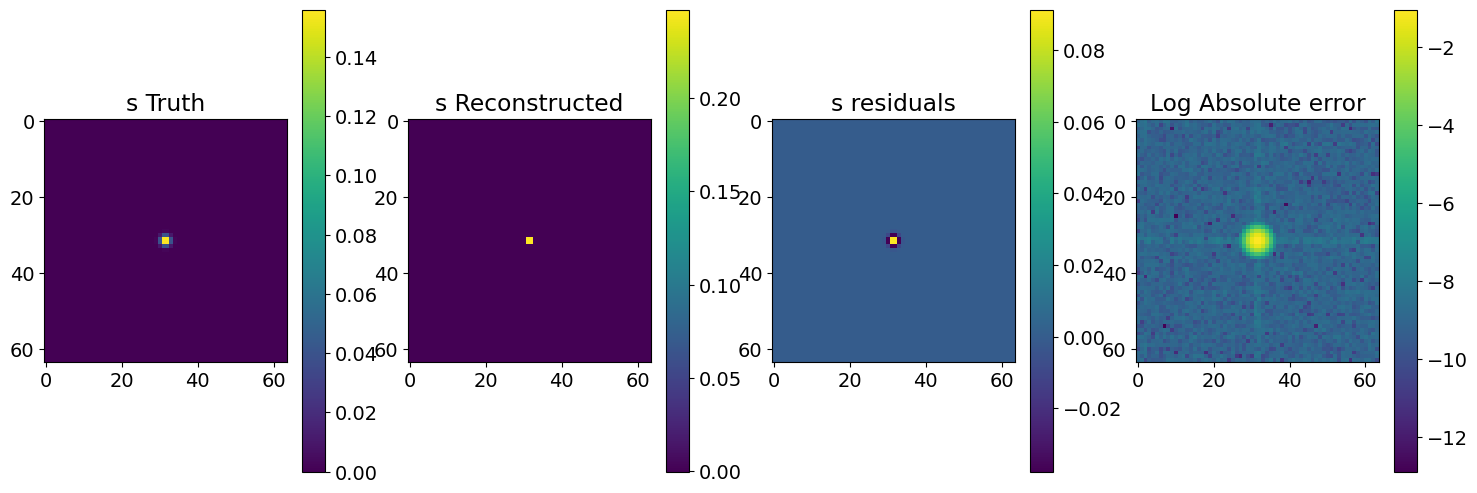

Max error / max PSF: 0.58601063
MAE : 0.00017856667


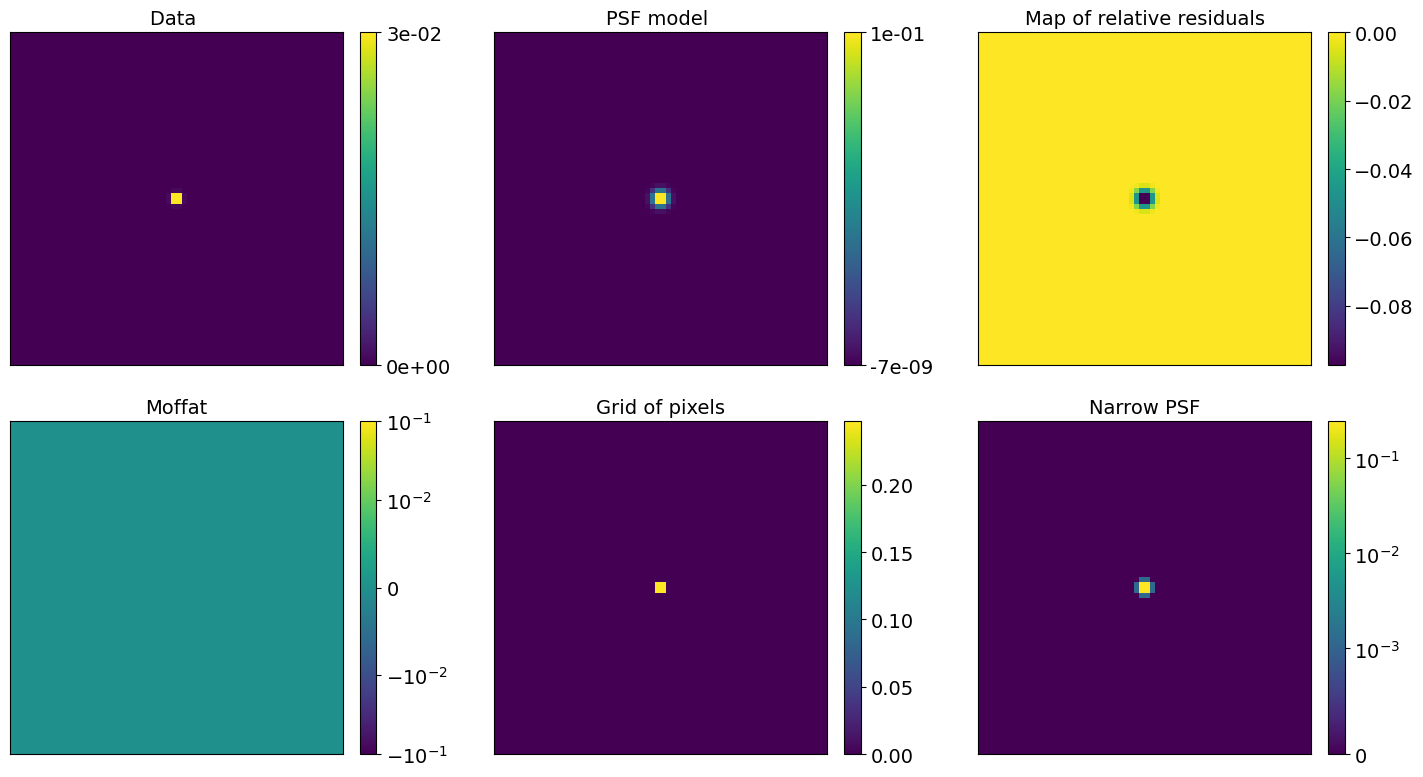

Max error / max PSF, full PSF: 3.754416
MAE : 0.00021752414
#############################################
Subsampling in: 3 Increase factor: 0.3333333333333333
Original PSF size: 65
Subsampling out: 1
1.0 1.0
(65, 65) (65, 65)


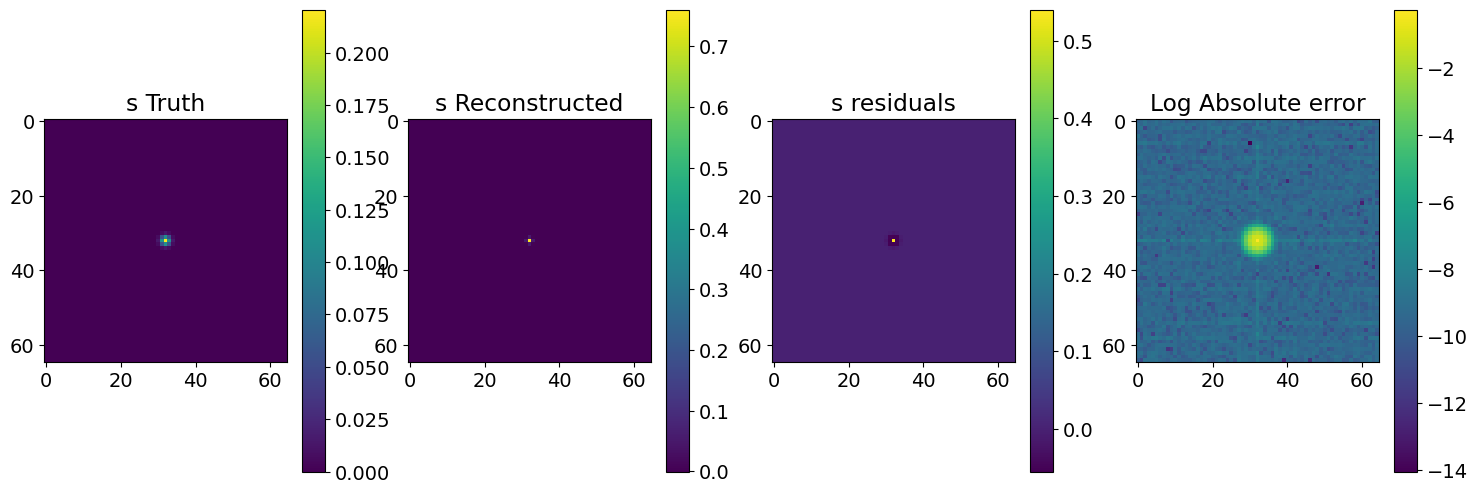

Max error / max PSF: 2.4486628
MAE : 0.0002557453


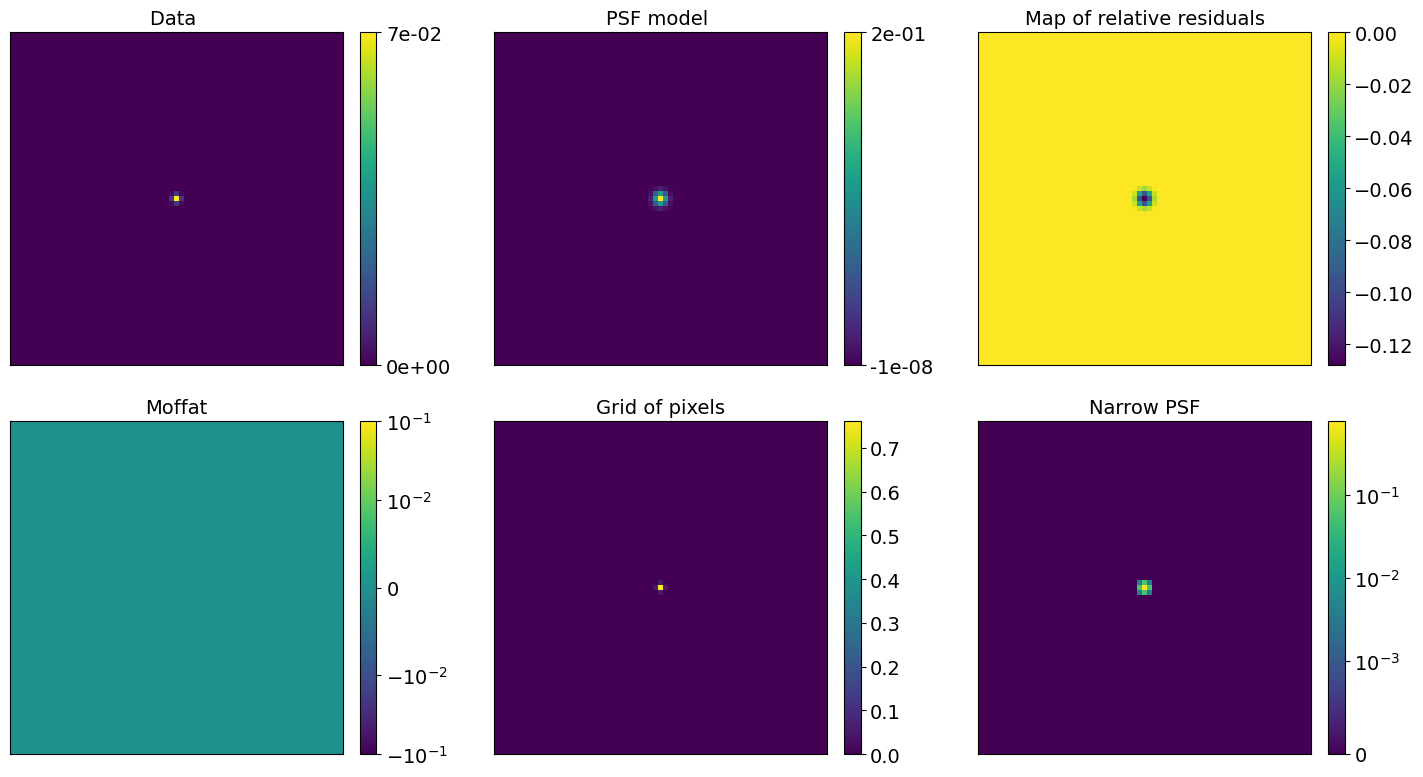

Max error / max PSF, full PSF: 1.9673542
MAE : 0.00020988967
#############################################
Subsampling in: 4 Increase factor: 0.25
Original PSF size: 64
Subsampling out: 1
1.0 0.9999998
(64, 64) (64, 64)


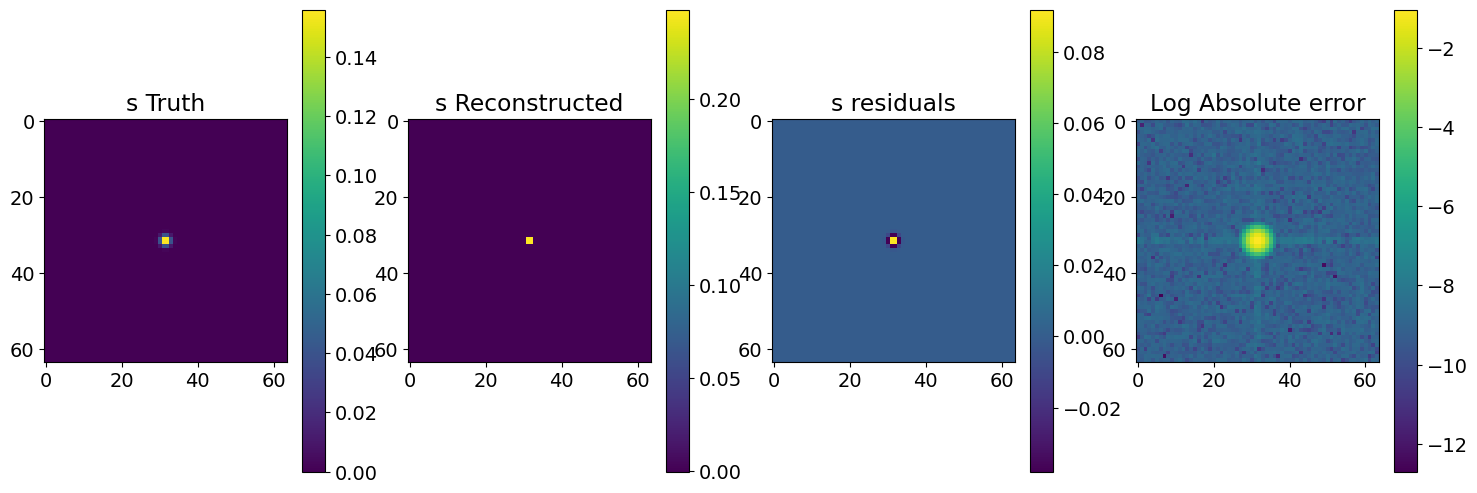

Max error / max PSF: 0.5891501
MAE : 0.00017952315


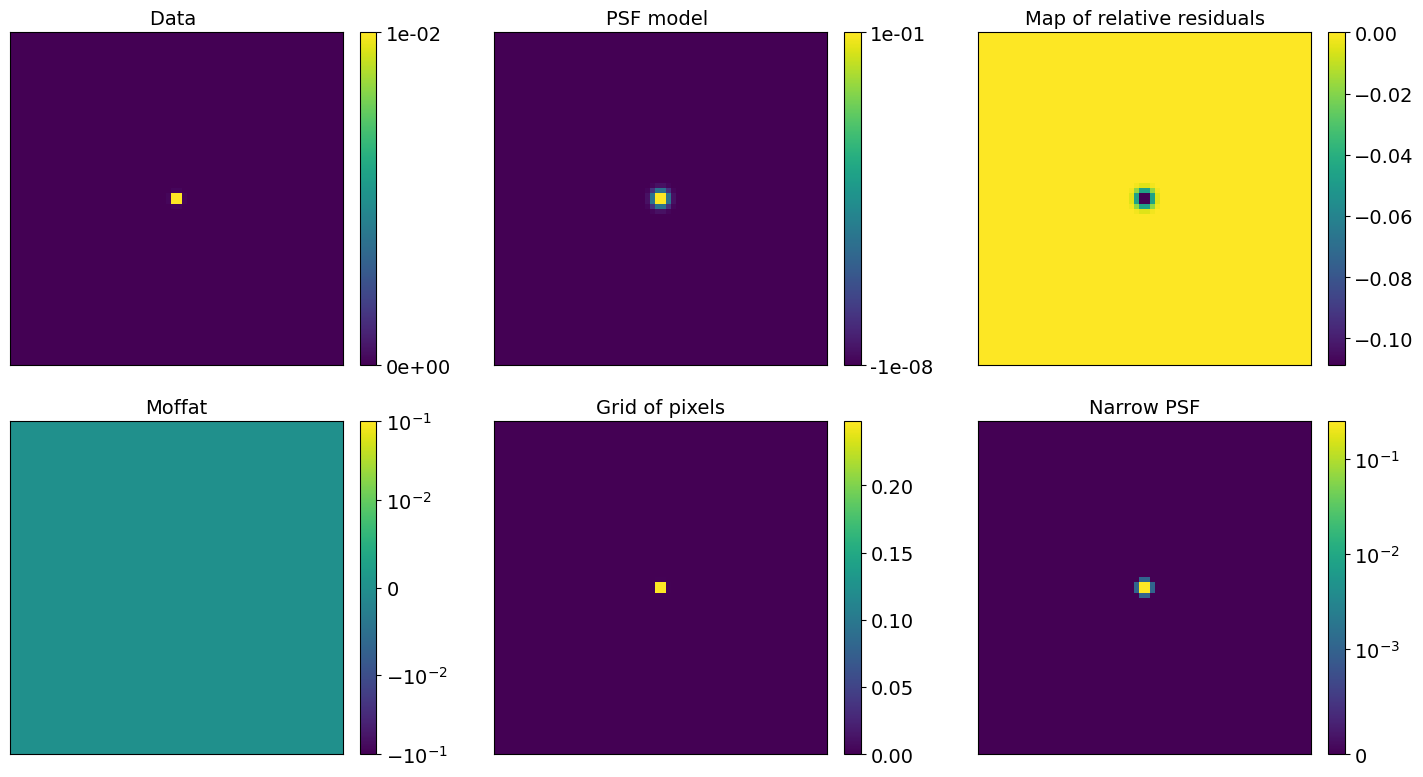

Max error / max PSF, full PSF: 7.4222107
MAE : 0.0002293326
#############################################
Subsampling in: 4 Increase factor: 0.25
Original PSF size: 65
Subsampling out: 1
1.0000001 1.0
(65, 65) (65, 65)


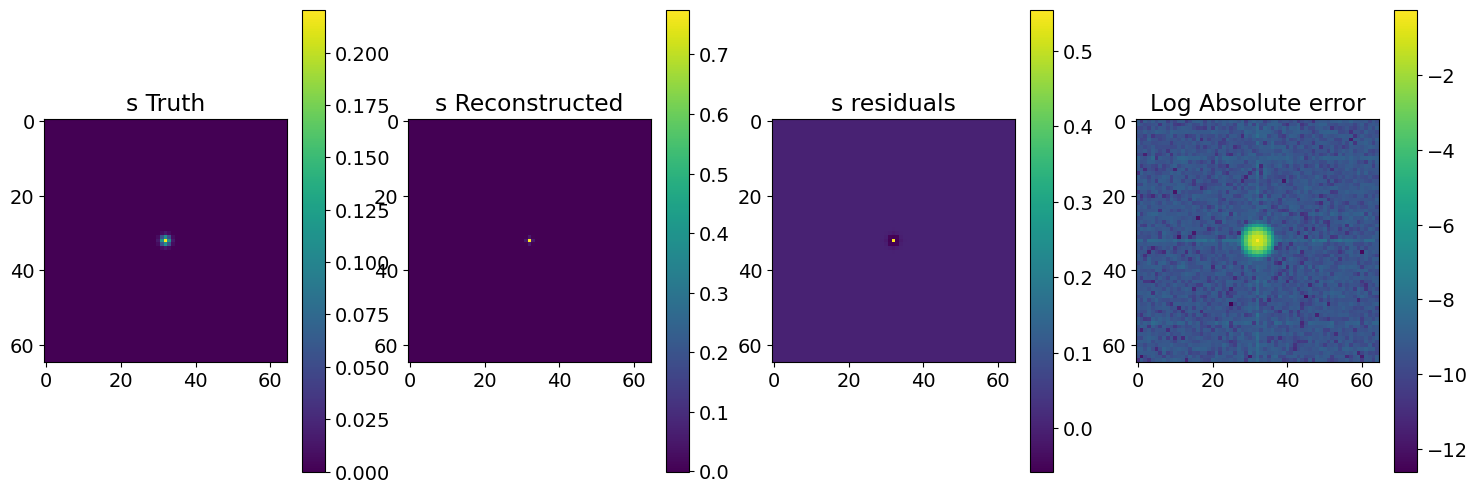

Max error / max PSF: 2.5138113
MAE : 0.00026254964


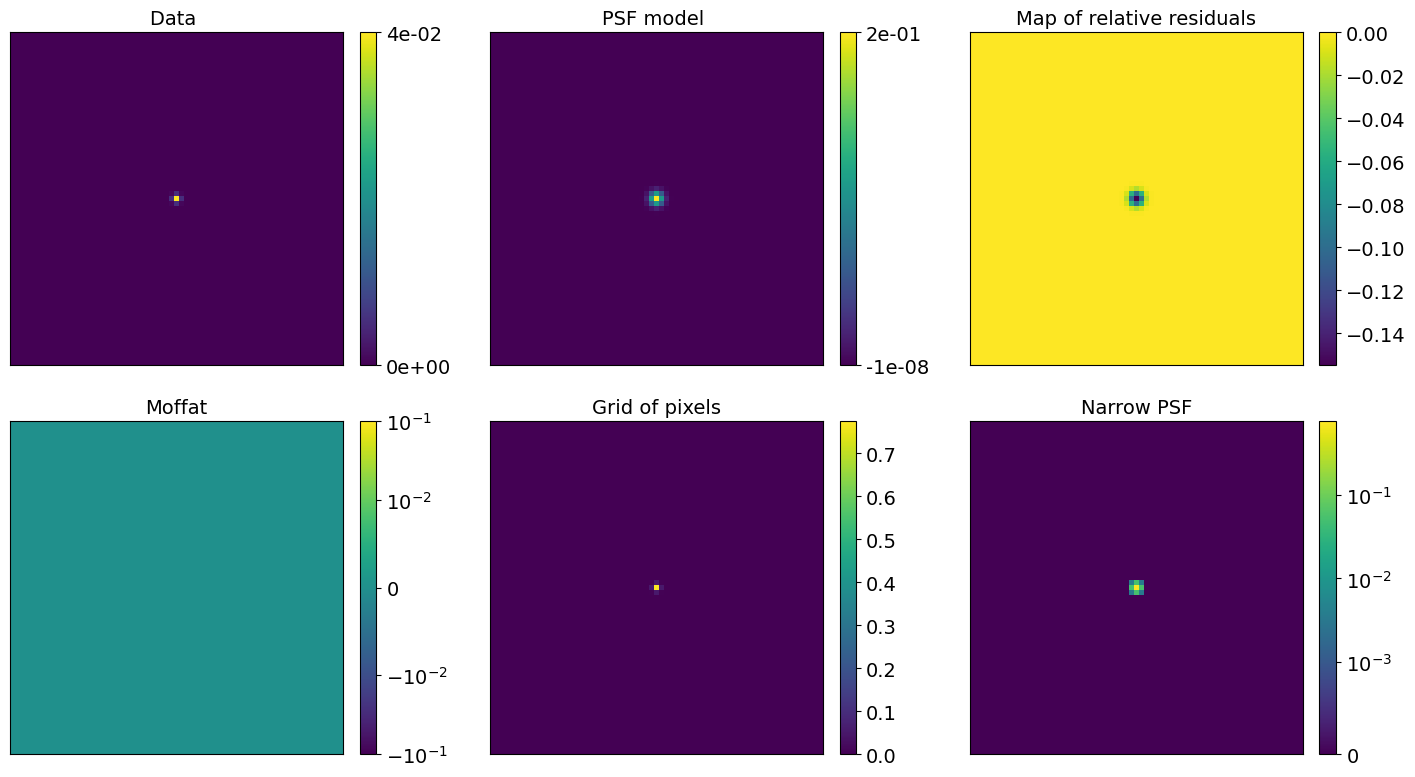

Max error / max PSF, full PSF: 3.842475
MAE : 0.00022145108


In [19]:
#checking if the convolution returns the correct thing: 
%load_ext autoreload
%autoreload 2

subsampling_ins = [2,3,4]
increase_factors = [0.5, 1/3., 0.25]
# subsampling_ins = [1]
npix_originals = [64,65]
# npix_originals = [64]

for subsampling_in, increase_factor in zip(subsampling_ins, increase_factors):
    for npix_original in npix_originals:
        print('#############################################')
        print('Subsampling in:', subsampling_in, 'Increase factor:', increase_factor)
        print('Original PSF size:', npix_original)

        subsampling_out = int(increase_factor * subsampling_in)
        print('Subsampling out:', subsampling_out)  
        npsf_in = int(npix_original * subsampling_in)
        npsf_out = int(npix_original * subsampling_out)

        sigma_narrowpsf = fwhm2sigma(2)
        sigma_gaussian = fwhm2sigma(2)
        sigma_fullpsf = fwhm2sigma(np.sqrt(2**2 + 2**2))

        x_in, y_in = make_grid(numPix=npsf_in, deltapix=1.)
        x_out, y_out = make_grid(numPix=npsf_out, deltapix=1.)

        PSF_model = gaussian_function(
                x=x_in, y=y_in,
                amp=1, sigma_x=sigma_fullpsf,
                sigma_y=sigma_fullpsf,
                center_x=0,
                center_y=0,
            ).reshape(npsf_in, npsf_in)

        narrow_psf_truth = gaussian_function(x=x_out, y=y_out,
                                            amp=1, sigma_x=sigma_narrowpsf,
                                            sigma_y=sigma_narrowpsf,
                                            center_x=0,
                                            center_y=0,
                                            ).reshape(npsf_out, npsf_out)


        narrow_psf_reconstructed = narrow_psf_from_model(PSF_model, subsampling_in, subsampling_out, mode='fourier_division')
        print(np.sum(narrow_psf_reconstructed), np.sum(narrow_psf_truth))
        print(np.shape(narrow_psf_reconstructed), np.shape(narrow_psf_truth))

        fig, axes = plt.subplots(1, 4, figsize=(18, 6))
        fig.colorbar(axes[0].imshow(narrow_psf_truth))
        axes[0].set_title('s Truth')
        fig.colorbar(axes[1].imshow(narrow_psf_reconstructed))
        axes[1].set_title('s Reconstructed')
        fig.colorbar(axes[2].imshow(narrow_psf_reconstructed - narrow_psf_truth))
        axes[2].set_title('s residuals')
        fig.colorbar(axes[3].imshow(np.log10(np.abs(narrow_psf_reconstructed - narrow_psf_truth))))
        axes[3].set_title('Log Absolute error')
        plt.show()

        # assert np.allclose(narrow_psf_reconstructed, narrow_psf_truth, atol=1e-1)

        print('Max error / max PSF:', np.max(np.abs(narrow_psf_reconstructed - narrow_psf_truth))/np.max(narrow_psf_truth))
        print('MAE :', np.mean(np.abs(narrow_psf_reconstructed - narrow_psf_truth)))


        # build the PFS class and check that the convolution works
        model = PSF(image_size=npsf_out, upsampling_factor=1, number_of_sources=1, include_moffat=False)
        PSF_in = skimage.transform.rescale(PSF_model, scale=increase_factor, order=1)
        kwargs, _, _, _ = model.smart_guess(PSF_in[np.newaxis, :, :])
        kwargs['kwargs_moffat']['C'] = 0.
        kwargs['kwargs_gaussian']['a'] = np.array([1.])
        kwargs['kwargs_gaussian']['x0'] = np.array([0.])
        kwargs['kwargs_gaussian']['y0'] = np.array([0.])
        kwargs['kwargs_background']['background'] = narrow_psf_reconstructed.ravel()

        sigma2 = np.ones_like(PSF_in[np.newaxis, :, :])
        fig2 = single_PSF_plot(model, PSF_in[np.newaxis, :, :], sigma2, kwargs)
        plt.show()

        plt.close('all')

        full_PFS_reconstructed = model.get_full_psf(**kwargs)

        print('Max error / max PSF, full PSF:', np.max(np.abs(full_PFS_reconstructed - PSF_in))/np.max(PSF_in))
        print('MAE :', np.mean(np.abs(full_PFS_reconstructed - PSF_in)))                              